# **HR Attrition Strategy Artefact**

**Libraries**

Importation of relevant libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mutual_info_score
from scipy.stats import entropy
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import time
!pip install py2neo
from py2neo import Graph, Node, Relationship
!pip install neo4j~=5.28.0
from neo4j import GraphDatabase
import networkx as nx
!pip install node2vec
from node2vec import Node2Vec
import joblib
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score
from collections import defaultdict
import shap


**Data Importation**

Connecting google drive to google colab

In [3]:
#importation of module that allows interaction of google drive with colab notebook
from google.colab import drive
#Connects google drive to directory /content/drive in google colab library
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importation of Data Sets

In [4]:
#Importation of raw data
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Sources/IBMHrDataSet.csv')

#importation of feature definitions
df_def = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Sources/Defintions.csv')

Sanity checking upload appears fine by checking the first 5 rows of each data frame.

In [5]:
print(df_raw.head())
#print(df[['EmployeeNumber', 'DailyRate', 'JobLevel', 'HourlyRate', 'MonthlyRate', 'MonthlyIncome', 'StandardHours' ]])

print(df_def.head())




   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

**Data Exploration**

Dissertation Reference, Chapter 5.1 Data Exploration, 5.1.1 Data Description

Establishing a high level row and column count.



In [6]:
#Shape returns a tuple representing the dimensionality of the Dataframe.

#Number of Rows
rows = df_raw.shape[0]
#Number of Columns
columns = df_raw.shape[1]

print("DataFrame Size:")
print("Rows:", rows)
print("Columns:", columns)



DataFrame Size:
Rows: 1470
Columns: 35


Creation and population of **d**ata**f**rame to summarise **D**ata **D**escription findings **DD_df** .

Addition of Columns to Data Description:
1. Columns Labels
2. Data Type
3. Feature Type
4. Unique Counts

In [7]:

#Creation of a new dataframe through function dataframe()
#parameter data, df.columns returns the column names of a dataframe
#parameter columns, label used for results frame in this case a column will have a label called 'Column Labels'
DD_df = pd.DataFrame(df_raw.columns, columns = ['Column Labels'] )


#Establishing the number of non-NA values for each column in the raw data set
#Axis parameter = 0 implies that counts are generated column wise
#numeric only = false implies that counts are not limited to data of type float, int or boolean
#returns a series. Summarising the non-NA entries for each column.
col_counts = df_raw.count(axis = 0, numeric_only=False)

#Conversion of series to Dataframe
df_col_counts = col_counts.to_frame(name='Filled Rows')

#Renaming index to "Column Labels"
df_col_counts = df_col_counts.rename_axis('Column Labels')

#Combination of two dataframes DD_df and df_col_counts
# on = 'Column Labels' specifies at what level to merge
# how - specifies how to merge
DD_df = DD_df.merge(df_col_counts, on='Column Labels', how='left')
#print(DD_df)

# The dtypes returns a series with the data type of each column.
datatypes = df_raw.dtypes

#conversion of series to dataframe
df_datatypes = datatypes.to_frame(name='Data Types')
#print(df_datatypes)
#Renaming index to 'Filled Rows'
df_datatypes = df_datatypes.rename_axis('Column Labels')

#Combination of two dataframes DD_df and df_datatypes
# on = 'Column Labels' specifies at what level to merge
# how - specifies how to merge
DD_df = DD_df.merge(df_datatypes, on='Column Labels', how='left')
#print(DD_df)


#nunique() returns a series with the number of distinct observations.
#by default NaN are not included in counts
unique_counts = df_raw.nunique()

#conversion of series to dataframe
df_unique_counts = unique_counts.to_frame(name='Unique Counts')

#Renaming index to 'Unique Counts'
df_unique_counts = df_unique_counts.rename_axis('Column Labels')

#Combination of two dataframes DD_df and df_unique_counts
# on = 'Column Labels' specifies at what level to merge
# how - specifies how to merge
DD_df = DD_df.merge(df_unique_counts, on='Column Labels', how='left')


#Additions of defintions to data description data frame
DD_df = DD_df.merge(df_def, on='Column Labels', how='left')
#print(DD_df)




##Segregating Columns between Numerical, Categorical
#Creation of simple dictionary to describe Feature_Type
feature_type_dict = {0:'Numerical_Continous', 1:'Categorical_Nominal', 2:'Categorical_Ordinal',
                     3: 'Numerical_Continous', 4: 'Categorical_Nominal', 5: 'Numerical_Continous',
                     6: 'Categorical_Ordinal', 7: 'Categorical_Nominal', 8: 'Numerical_Continous',
                     9: 'Categorical_Nominal', 10: 'Categorical_Ordinal', 11: 'Categorical_Nominal',
                     12: 'Numerical_Continous', 13: 'Categorical_Ordinal', 14: 'Categorical_Ordinal',
                     15: 'Categorical_Nominal', 16: 'Categorical_Ordinal', 17: 'Categorical_Nominal',
                     18: 'Numerical_Continous', 19: 'Numerical_Continous', 20: 'Numerical_Discrete',
                     21: 'Categorical_Nominal', 22: 'Categorical_Nominal', 23: 'Numerical_Continous',
                     24: 'Categorical_Ordinal', 25: 'Categorical_Ordinal', 26: 'Numerical_Continous',
                     27: 'Categorical_Ordinal', 28: 'Numerical_Continous', 29: 'Numerical_Discrete',
                     30: 'Categorical_Ordinal', 31: 'Numerical_Continous', 32: 'Numerical_Continous',
                     33: 'Numerical_Continous', 34: 'Numerical_Continous'


                     }
#print(feature_type_dict)

#Adding columns with phyton dictionary
#The index values of DD_df are mapped towards the key value mapping of the dictionary
DD_df['Feature Type'] = DD_df.index.map(feature_type_dict)
print(DD_df)



               Column Labels  Filled Rows Data Types  Unique Counts  \
0                        Age         1470      int64             43   
1                  Attrition         1470     object              2   
2             BusinessTravel         1470     object              3   
3                  DailyRate         1470      int64            886   
4                 Department         1470     object              3   
5           DistanceFromHome         1470      int64             29   
6                  Education         1470      int64              5   
7             EducationField         1470     object              6   
8              EmployeeCount         1470      int64              1   
9             EmployeeNumber         1470      int64           1470   
10   EnvironmentSatisfaction         1470      int64              4   
11                    Gender         1470     object              2   
12                HourlyRate         1470      int64             71   
13    

Addition of Columns to Data Description:
1. IQR
2. LR
3. UR
4. Has Outliers
5. Number of Outliers

In [8]:
#Addition of statistical data to DD_df
#function to calculate interquartile range, first quartile, third quartile, lower range and upper range.
def iqr(x):
  Q1 = x.quantile(0.25)
  Q3 = x.quantile(0.75)
  IQR = Q3 - Q1
  #This is to stop negative values as in this context it does not make sense
  lr = max((Q1 - 1.5*IQR), 0)
  ur = Q3 + 1.5*IQR
  return pd.Series({'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lr': lr, 'Ur':ur})



#Identify from DD_df only those column labels having a feature type of Numerical continous or Numerical discrete
#Creation of a bool series from isin()
numerical_colums = DD_df['Feature Type'].isin(['Numerical_Continous', 'Numerical_Discrete'])

#displaying data with required feature types only
new = DD_df[numerical_colums]


#Dropping of columns
#Parameters identify the columns names
#Axis = 1 makes clear dropping of columns
new = new.drop(['Filled Rows', 'Data Types', 'Unique Counts', 'Description', 'Feature Type' ], axis =1)

#List of columns to keep
new = new['Column Labels'].tolist()
#print(new)

#Reduction of df_raw to only those columns in list
df_raw_numerical = df_raw[new]


#Calculation of IQR, Q1, Q3, LR, UR for all those columns of feature type numerical
IQR = df_raw_numerical.apply(iqr)


#pivoting of IQR table to faciliate joining with DD_df
IQR_pivoted = pd.pivot_table(IQR, columns=['Q1', 'Q3', 'IQR', 'Lr', 'Ur'])

#When resetting the index the old index is added as a column and a new sequential index is used.
IQR_pivoted.index.name = 'Column Labels'
IQR_pivoted = IQR_pivoted.reset_index()
#print(IQR_pivoted)

#Enriching DD_df with statistical data through a left join
DD_df = DD_df.merge(IQR_pivoted, on='Column Labels', how='left')

#Summarising if numerical column labels have outliers and number of outliers

# Establishing the index as 'Column Labels' and extracting a relevant feature i.e. Lr or Ur as part of a series
# A simple series with column Labels and their relevant limits.
lower_limit = DD_df.set_index('Column Labels')['Lr']
upper_limit = DD_df.set_index('Column Labels')['Ur']


# The lt() method compares each column in a dataframe against the series in questions and checks if it is less than a specified value.
# The gt() method compares each column in a dataframe against the series in questions and checks if it is more than a specified value.
#Returns a dataframe with boolean true/false for each comparision
lr_less = df_raw.lt(lower_limit, axis=1)
ur_more = df_raw.gt(upper_limit, axis=1)
#print(lr_less)

#Count number of true values
# i.e. those numerical values that fall outside LR and UR
count_lr_less = lr_less.sum()
count_ur_more = ur_more.sum()


#Conversion into dataframe for LR analysis
count_lr_less = pd.DataFrame(count_lr_less, columns = ['instances below'])
count_lr_less.index.name = 'Column Labels'
count_lr_less = count_lr_less.reset_index()


#Conversion into dataframe for UR analysis
count_ur_more = pd.DataFrame(count_ur_more, columns = ['instances above'])
count_ur_more.index.name = 'Column Labels'
count_ur_more = count_ur_more.reset_index()


#Creation of a single Dataframe summarising both LR and UR analysis.
newdf = count_lr_less.merge(count_ur_more, on='Column Labels', how='inner')

#Enriching dataframe by considering the number of outliers i.e. in violation of both LR and UR limits
newdf['Number Of Outliers'] = newdf['instances below'] + newdf['instances above']

#Enriching dataframe by classifying if column labels have outliers.
newdf['Has Outliers?'] = np.where(newdf['Number Of Outliers'] > 0, 'True', 'False')

#Merging outlier analysis results with main data description table
DD_df = DD_df.merge(newdf, on='Column Labels', how='left')





In [9]:
#Simple Sanity Check
#print(DD_df)

Addition of Columns to Data Description:
1. Is Discriminatory Feature
2. Action Required

In [10]:



#Creation of Feature 'Is Discriminatory Feature' and by default populating it with N/A
DD_df['Is Discriminatory Feature?'] = 'N/A'

#Over writing the column is discriminatory feature with a Y for certain column labels
DD_df.loc[DD_df['Column Labels'] == 'Age', 'Is Discriminatory Feature?'] = 'Y'
DD_df.loc[DD_df['Column Labels'] == 'Gender', 'Is Discriminatory Feature?'] = 'Y'
DD_df.loc[DD_df['Column Labels'] == 'MaritalStatus', 'Is Discriminatory Feature?'] = 'Y'


#Creation of feature 'Action Required' and by default populating it with None
DD_df['Action Required'] = 'None'

#Updating column Action Required by considering cardinality
DD_df.loc[DD_df['Unique Counts'] == 1, 'Action Required'] = 'Planned Removal, constant across all employees.'

#Updating column Action Required by considering discriminatory features
DD_df.loc[DD_df['Is Discriminatory Feature?'] == 'Y', 'Action Required'] = 'Planned Removal,  discriminatory feature '


#Updating column Action Required by considering presence of outliers
DD_df.loc[DD_df['Has Outliers?'] == 'True', 'Action Required'] = 'Outlier Capping and flooring'

#Updating Action Required label of self-reporting features
DD_df.loc[DD_df['Column Labels'] == 'EnvironmentSatisfaction', 'Action Required'] = 'Planned Removal, self-reporting feature'
DD_df.loc[DD_df['Column Labels'] == 'JobSatisfaction', 'Action Required'] = 'Planned Removal, self-reporting feature'
DD_df.loc[DD_df['Column Labels'] == 'WorkLifeBalance', 'Action Required'] = 'Planned Removal, self-reporting feature'
DD_df.loc[DD_df['Column Labels'] == 'RelationshipSatisfaction', 'Action Required'] = 'Planned Removal, self-reporting feature'

#Updating Action Required label of features 'HourlyRate', DailyRate and 'HourlyRate
DD_df.loc[DD_df['Column Labels'] == 'HourlyRate', 'Action Required'] = 'Planned Removal, corrupted data'
DD_df.loc[DD_df['Column Labels'] == 'MonthlyRate', 'Action Required'] = 'Planned Removal, corrupted data'
DD_df.loc[DD_df['Column Labels'] == 'DailyRate', 'Action Required'] = 'Planned Removal, corrupted data'


## Formatting DD_df
## Ensuring the features are placed in an order which make sense.
DD_df = DD_df[['Column Labels', 'Description', 'Data Types', 'Feature Type', 'Unique Counts', 'Q1', 'Q3', 'IQR', 'Lr', 'Ur', 'Has Outliers?', 'Number Of Outliers', 'Is Discriminatory Feature?', 'Action Required'  ]]
print(DD_df)

               Column Labels  \
0                        Age   
1                  Attrition   
2             BusinessTravel   
3                  DailyRate   
4                 Department   
5           DistanceFromHome   
6                  Education   
7             EducationField   
8              EmployeeCount   
9             EmployeeNumber   
10   EnvironmentSatisfaction   
11                    Gender   
12                HourlyRate   
13            JobInvolvement   
14                  JobLevel   
15                   JobRole   
16           JobSatisfaction   
17             MaritalStatus   
18             MonthlyIncome   
19               MonthlyRate   
20        NumCompaniesWorked   
21                    Over18   
22                  OverTime   
23         PercentSalaryHike   
24         PerformanceRating   
25  RelationshipSatisfaction   
26             StandardHours   
27          StockOptionLevel   
28         TotalWorkingYears   
29     TrainingTimesLastYear   
30      

In [11]:
#Sanity Check
#print(DD_df)

Investigating Daily Rate, Hourly Rate, Monthly Rate, Monthly Income since these should be directly proportional to one another.


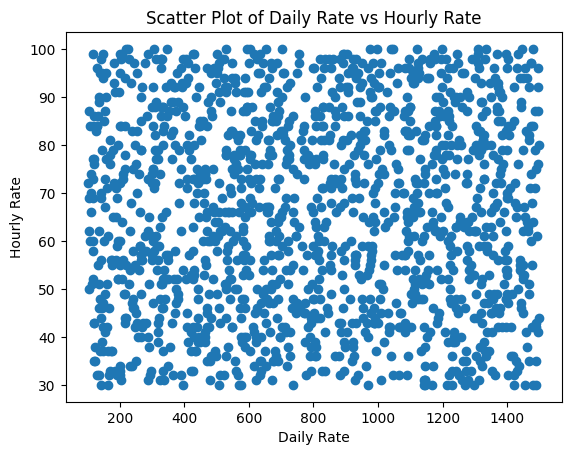

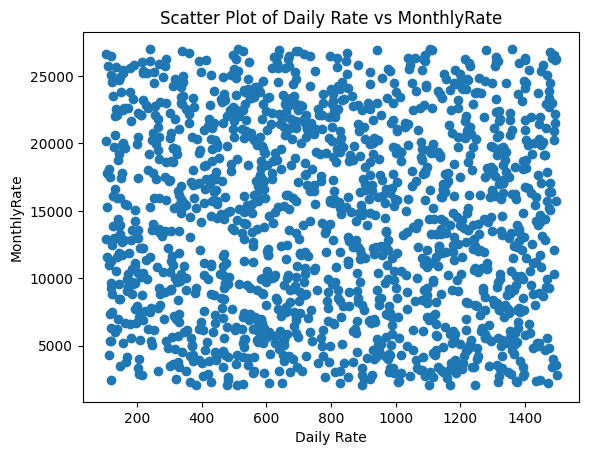

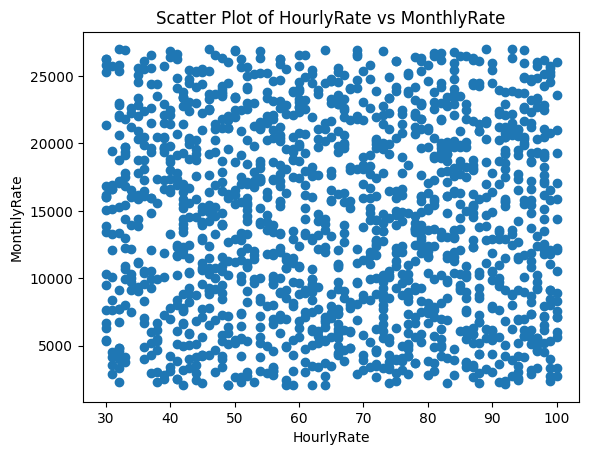

In [12]:
#creation of dataframe including features of interest
df_rates = df_raw[['DailyRate', 'HourlyRate', 'MonthlyRate']]
#print(df_rates)

#Daily Rate versus Hourly Rate
#plt.scatter plots one dot for each observation. requires two arrays of the same length one for values of x-axis and one for values of y-axis
plt.scatter(df_rates['DailyRate'], df_rates['HourlyRate'])
#Labels and title of graph
plt.xlabel('Daily Rate')
plt.ylabel('Hourly Rate')
plt.title('Scatter Plot of Daily Rate vs Hourly Rate')
plt.show()

#Daily Rate and Monthly Rate
#plt.scatter plots one dot for each observation. requires two arrays of the same length one for values of x-axis and one for values of y-axis
plt.scatter(df_rates['DailyRate'], df_rates['MonthlyRate'])
#Labels and title of graph
plt.xlabel('Daily Rate')
plt.ylabel('MonthlyRate')
plt.title('Scatter Plot of Daily Rate vs MonthlyRate')
plt.show()

#Hourly Rate versus Monthly Rate
#plt.scatter plots one dot for each observation. requires two arrays of the same length one for values of x-axis and one for values of y-axis
plt.scatter(df_rates['HourlyRate'], df_rates['MonthlyRate'])
#Labels and title of graph
plt.xlabel('HourlyRate')
plt.ylabel('MonthlyRate')
plt.title('Scatter Plot of HourlyRate vs MonthlyRate')
plt.show()

In [13]:

# Export Data Description to Excel
# and insert into Appendix F of dissertation
DD_df.to_excel('DD_df.xlsx', sheet_name='Sheet1', index=False)

**Data Exploration**

Dissertation Reference, Chapter 5.1 Data Exploration, 5.1.2 Exploration Description

Univariate analysis of various features that have not been identified for removal.



1. Box Plots for Numerical features

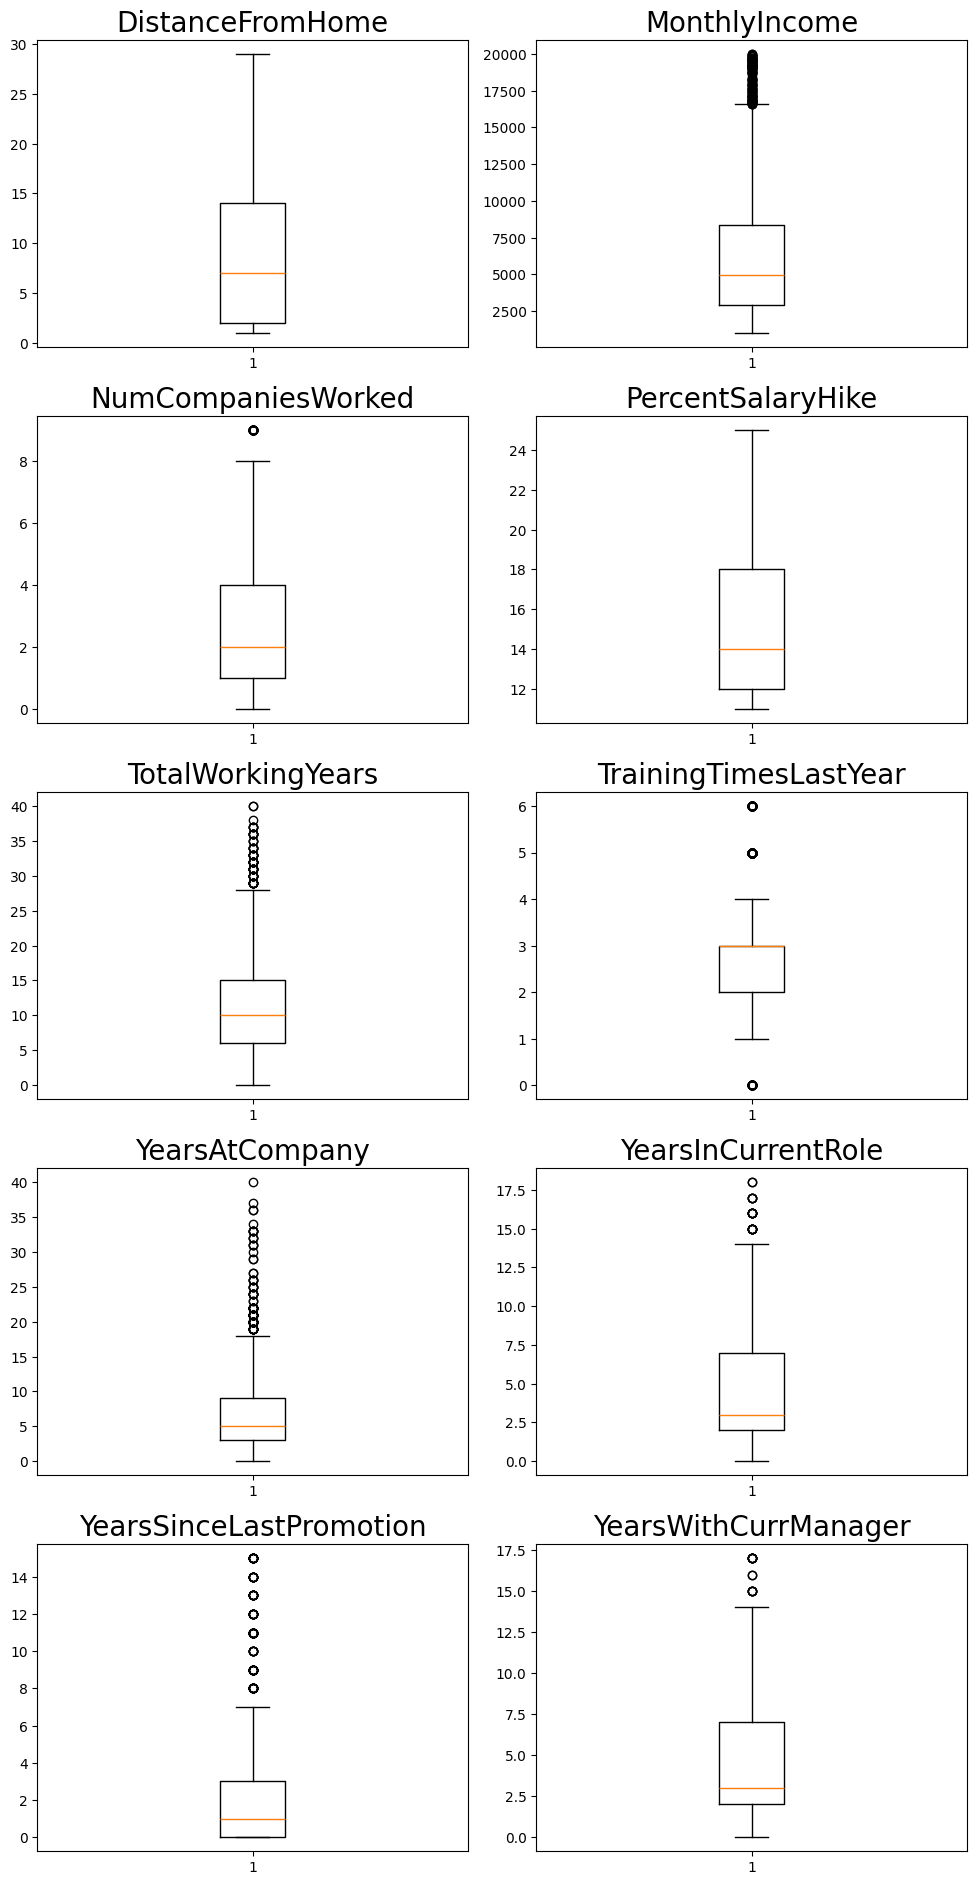

In [14]:

# creation of dataframe which includes only numerical features
# note those features with a cardinality of 1 where removed.
df_numerical = df_raw[['DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
                       'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
                       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']]


#use of subplots to help organise multiple plots within a grid
#nrows, ncols = number of rows/columns of subplot grid.
#figsize is the figure dimensions of the returned plot element fig.
#axs encapsulates all elements of an individual sub plot in a figure
fig, axs = plt.subplots(nrows = 8, ncols= 2, figsize =(10,30))

#iterating through the grid set up above
for i, ax in enumerate(axs.flat):
  #only use an availiable grid if their is a corresponding feature left to plot.
  if i < len(df_numerical.columns):
    #Drawng of box plot where df_numerical.iloc[i:,] represents the input data
    #Select all rows belong to column i from dataframe df_numerical
    ax.boxplot(df_numerical.iloc[:,i])
    #Set a title for the axes
    # text to use for title is the column name as found in dataframe
    #Setting of font size and weight
    ax.set_title(df_numerical.columns[i], fontsize = 20, fontweight = 'medium')


  else:
    #Hides grid/ais object that is not being used.
    ax.set_visible(False)

#helps maintain the padding between and around subplots.
plt.tight_layout()




2. Histograms for Numerical Features



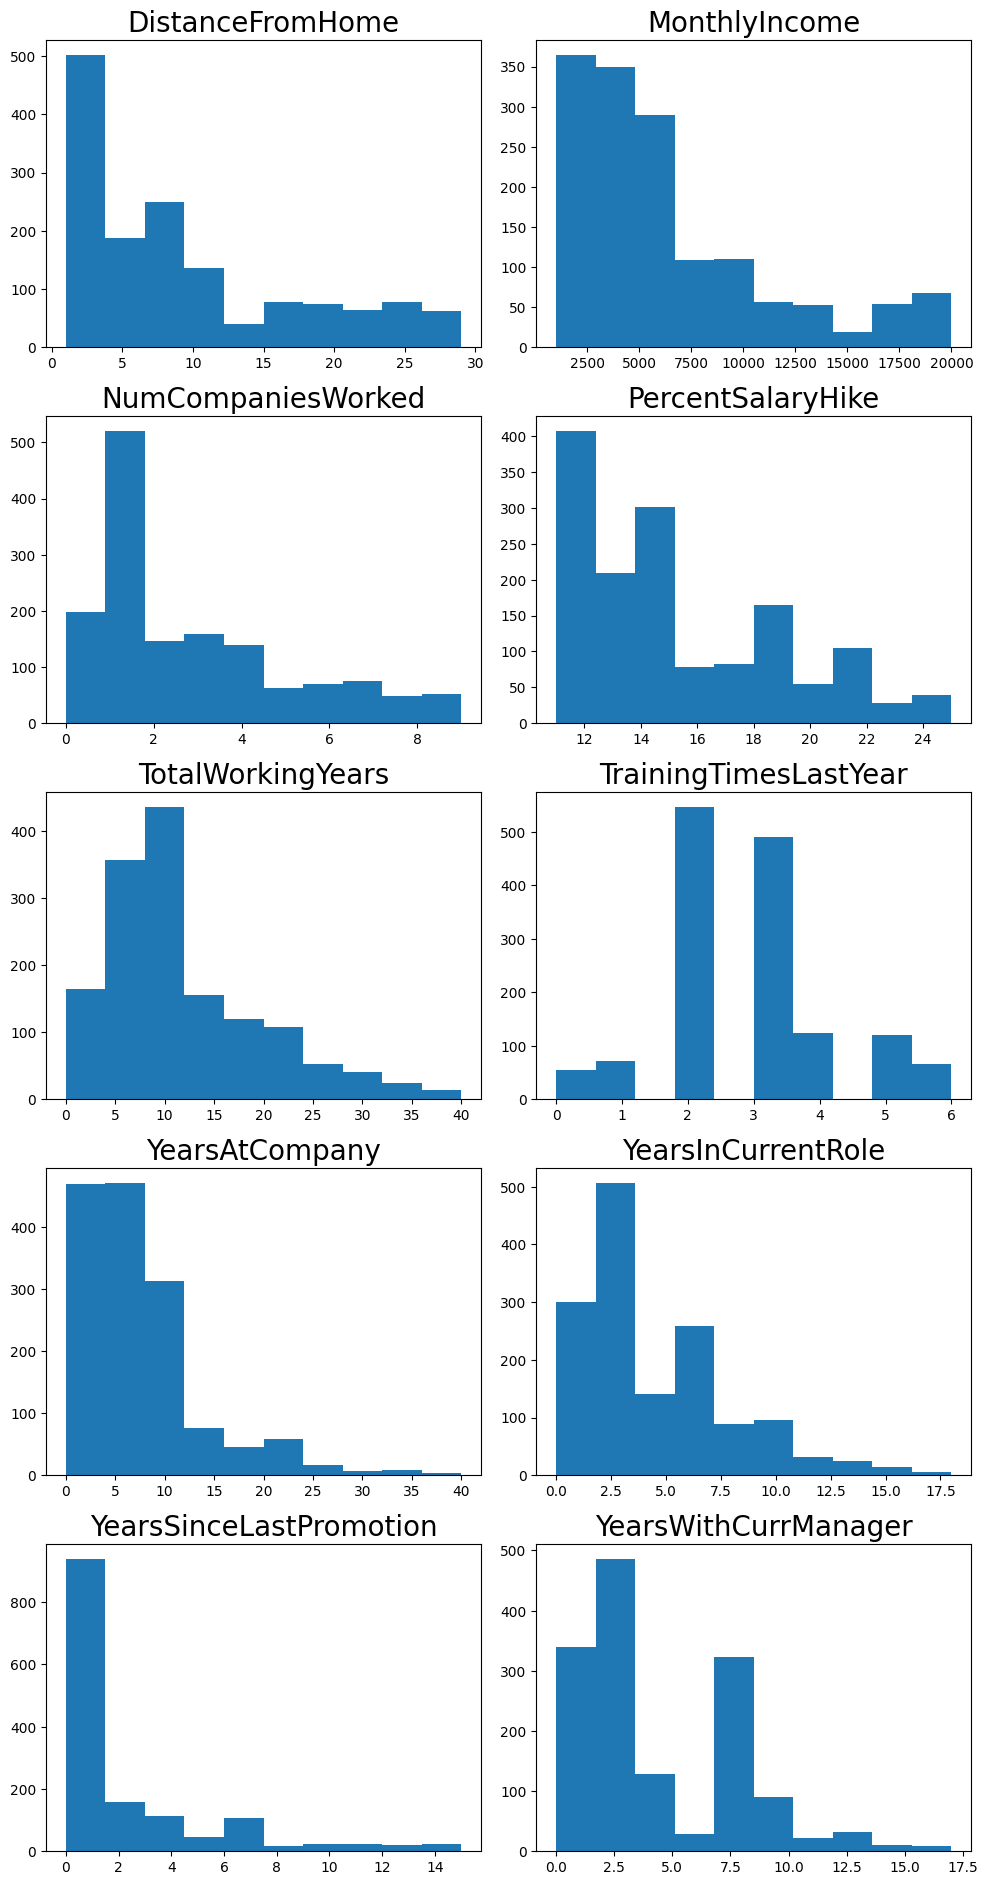

In [15]:
# creation of dataframe which includes only numerical features
# note those features with a cardinality of 1 where removed.
df_numerical = df_raw[['DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
                       'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
                       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']]


#use of subplots to help organise multiple plots within a grid
#nrows, ncols = number of rows/columns of subplot grid.
#figsize is the figure dimensions of the returned plot element fig.
#axs encapsulates all elements of an individual sub plot in a figure
fig, axs = plt.subplots(nrows = 8, ncols= 2, figsize =(10,30))

#iterating through the grid set up above
for i, ax in enumerate(axs.flat):
  #only use an availiable grid if their is a corresponding feature left to plot.
  if i < len(df_numerical.columns):
    #Drawng of box plot where df_numerical.iloc[i:,] represents the input data
    #Select all rows belong to column i from dataframe df_numerical
    ax.hist(df_numerical.iloc[:,i])
    #Set a title for the axes
    # text to use for title is the column name as found in dataframe
    #Setting of font size and weight
    ax.set_title(df_numerical.columns[i], fontsize = 20, fontweight = 'medium')


  else:
    #Hides grid/ais object that is not being used.
    ax.set_visible(False)

#helps maintain the padding between and around subplots.
plt.tight_layout()


3. Count plots for Categorical Features

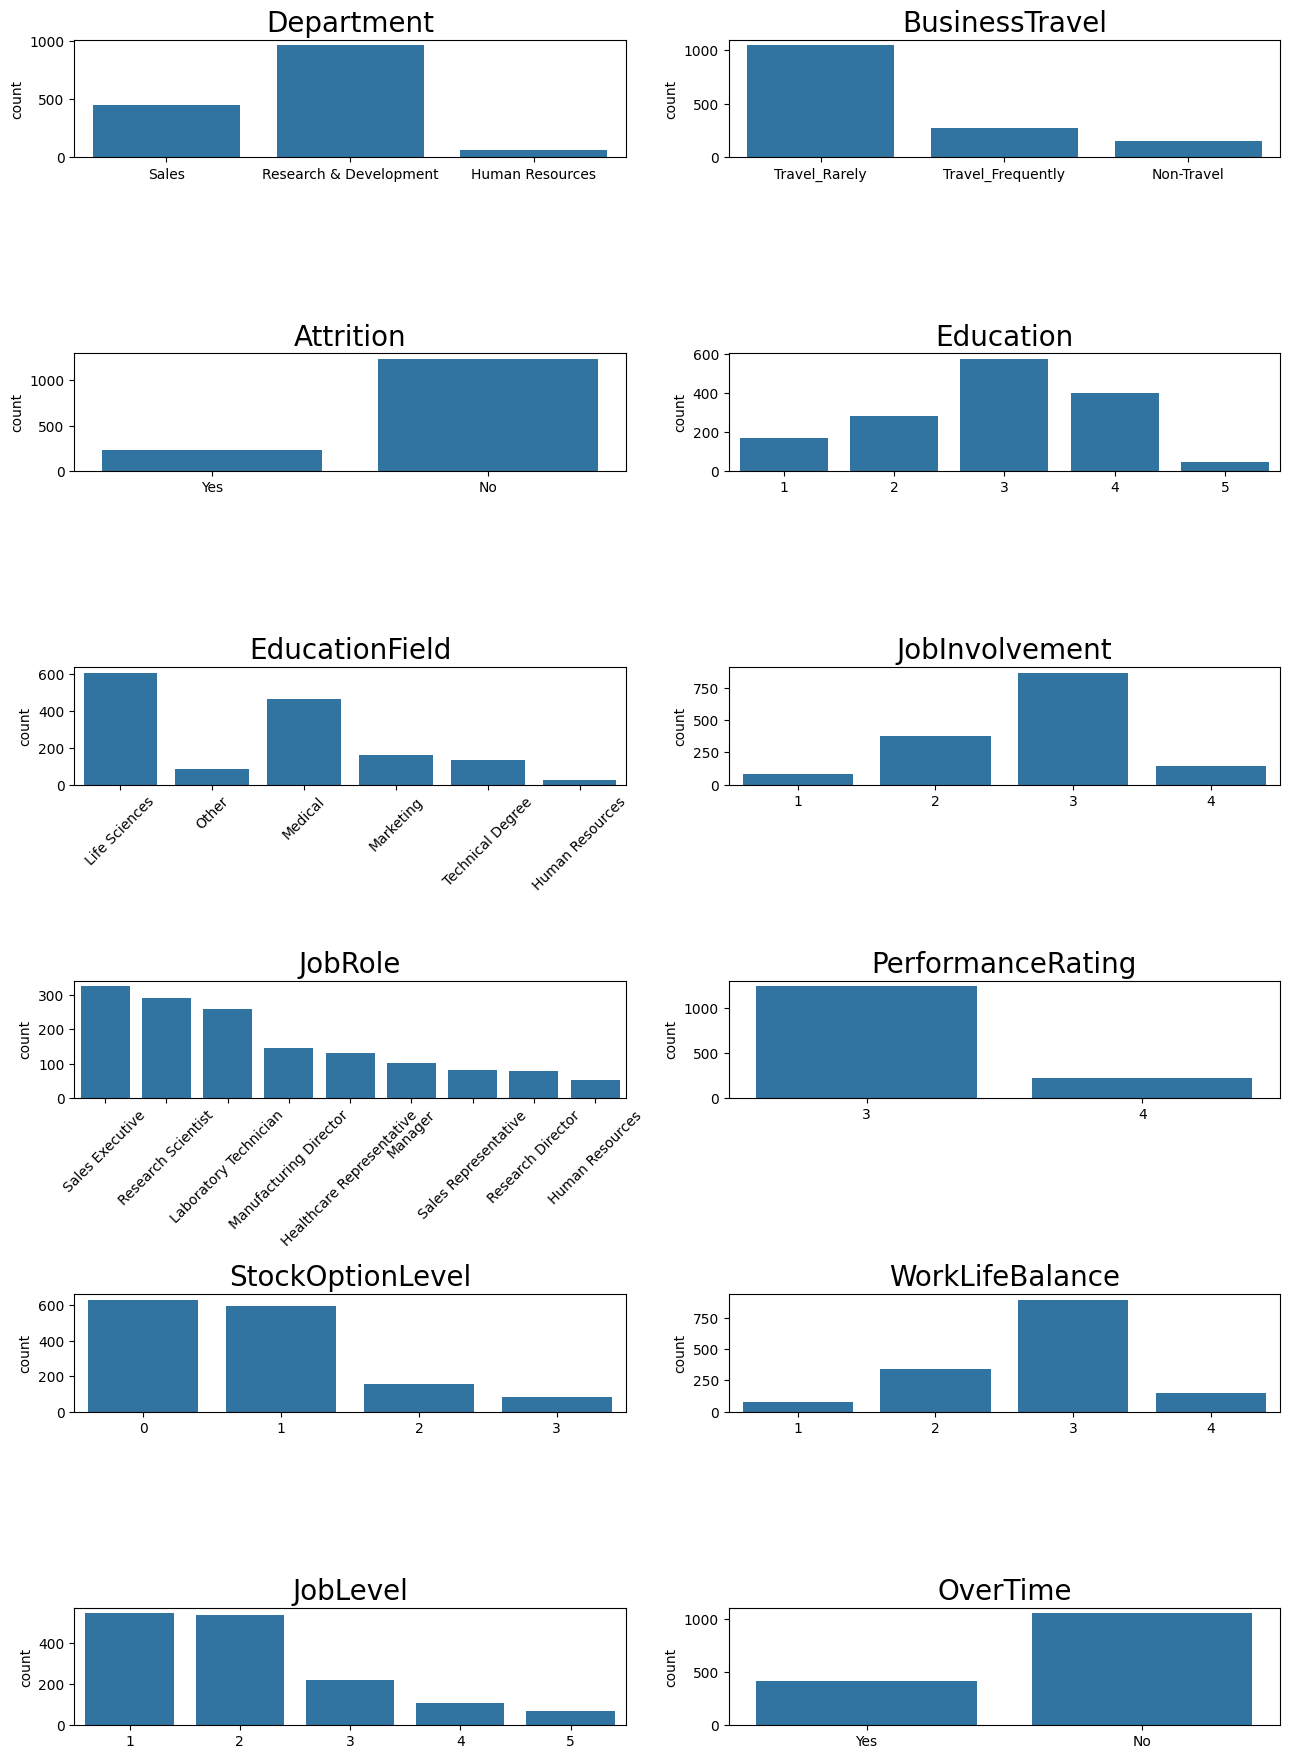

In [16]:

# creation of dataframe which includes only categorical features
# note those features with a cardinality of 1 where removed.
df_categorical = df_raw[['Department', 'BusinessTravel', 'Attrition', 'Education', 'EducationField',
                         'JobInvolvement', 'JobRole', 'PerformanceRating', 'StockOptionLevel', 'WorkLifeBalance',
                         'JobLevel', 'OverTime'  ]]

#use of subplots to help organise multiple plots within a grid
#nrows, ncols = number of rows/columns of subplot grid.
#figsize is the figure dimensions of the returned plot element fig.
#axs encapsulates all elements of an individual sub plot in a figure
fig, axs = plt.subplots(nrows = 10, ncols= 2, figsize =(13,30))


#iterating through the grid set up above
for i, ax in enumerate(axs.flat):
  #only use an availiable grid if their is a corresponding feature left to plot.
  if i < len(df_categorical.columns):
    #Saving column name is variable col.
    col = df_categorical.columns[i]


    sns.countplot(x=col, data=df_categorical, ax=ax)
    ax.set_xlabel("")
    ax.set_title(f"{col}", fontsize=20, fontweight='medium')
    # Rotate x-axis labels
    if (col == 'EducationField') or (col == 'JobRole'):
      ax.tick_params(axis='x', rotation=45)

  else:
    #Hides grid/ais object that is not being used.
    ax.set_visible(False)

#helps maintain the padding between and around subplots.
plt.tight_layout()






**Data Pre-Processing**

Dissertation Reference, Chapter 5.2.1 Initial Feature Selection
This is stored in **p**re-**p**rocessing **d**ata**f**rame called **df_pp**







Initial Feature Reduction and saving EmployeeNumber

In [17]:

#Backing up of original dataframe into new dataframe called df_RAW to preserve an unmodified version of data.
df_RAW = df_raw.copy()

#Storing Employee Numbers seperatly
EmployeeNumber = df_raw['EmployeeNumber']


#Creation of dataframe for pre-processing called df_pp
#Columns where dropped in line with Appendix F: Data Description
df_pp = df_raw.drop(['Age', 'DailyRate', 'EmployeeCount', 'HourlyRate', 'MonthlyRate', 'Over18', 'StandardHours', 'EmployeeNumber', 'Gender', 'EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'MaritalStatus' ], axis=1)
print(df_pp)

Column Labels Attrition     BusinessTravel              Department  \
0                   Yes      Travel_Rarely                   Sales   
1                    No  Travel_Frequently  Research & Development   
2                   Yes      Travel_Rarely  Research & Development   
3                    No  Travel_Frequently  Research & Development   
4                    No      Travel_Rarely  Research & Development   
...                 ...                ...                     ...   
1465                 No  Travel_Frequently  Research & Development   
1466                 No      Travel_Rarely  Research & Development   
1467                 No      Travel_Rarely  Research & Development   
1468                 No  Travel_Frequently                   Sales   
1469                 No      Travel_Rarely  Research & Development   

Column Labels  DistanceFromHome  Education EducationField  JobInvolvement  \
0                             1          2  Life Sciences               3   
1    

Dissertation Reference, Chapter 5.2.2 Data Cleaning

Fixing of outliers, the new values are stored in **df_pp**





In [18]:
print(df_pp)
#print(DD_df)

#Fixing outliers for feature: MonthlyIncome
#Saving the upper and lower limit for MonthlyIncome
lower_limit_monthly_income = DD_df.at[18,'Lr']
upper_limit_monthly_income = DD_df.at[18,'Ur']

#Capping extreme values to predefined upper and lower bounds
df_pp['MonthlyIncome'] = np.clip(df_pp['MonthlyIncome'], lower_limit_monthly_income, upper_limit_monthly_income)

#Fixing outliers for feature: NumCompaniesWorked
#Saving the upper and lower limit for NumCompaniesWorked

lower_limit_num_companies_worked = DD_df.at[20, 'Lr']
upper_limit_num_companies_worked = DD_df.at[20, 'Ur']

#Capping extreme values to predefined upper and lower bounds
df_pp['NumCompaniesWorked'] = np.clip(df_pp['NumCompaniesWorked'], lower_limit_num_companies_worked, upper_limit_num_companies_worked)

#Fixing outliers for feature: TotalWorkingYears
#Saving the upper and lower limit for TotalWorkingYears
lower_limit_TotalWorkingYears = DD_df.at[28,'Lr']
upper_limit_TotalWorkingYears = DD_df.at[28,'Ur']


#Capping extreme values to predefined upper and lower bounds
df_pp['TotalWorkingYears'] = np.clip(df_pp['TotalWorkingYears'], lower_limit_TotalWorkingYears, upper_limit_TotalWorkingYears)


#Fixing outliers for feature: TrainingTimesLastYear
#Saving the upper and lower limit for TrainingTimesLastYear
lower_limit_TrainingTimesLastYear = DD_df.at[29,'Lr']
upper_limit_TrainingTimesLastYear = DD_df.at[29,'Ur']

#Capping extreme values to predefined upper and lower bounds
df_pp['TrainingTimesLastYear'] = np.clip(df_pp['TrainingTimesLastYear'], lower_limit_TrainingTimesLastYear, upper_limit_TrainingTimesLastYear)

#Fixing outliers for feature: YearsAtCompany
#Saving the upper and lower limit for YearsAtCompany
lower_limit_YearsAtCompany = DD_df.at[31,'Lr']
upper_limit_YearsAtCompany = DD_df.at[31,'Ur']

#Capping extreme values to predefined upper and lower bounds
df_pp['YearsAtCompany'] = np.clip(df_pp['YearsAtCompany'], lower_limit_YearsAtCompany, upper_limit_YearsAtCompany)

#Fixing outliers for feature: YearsInCurrentRole
#Saving the upper and lower limit for YearsInCurrentRole
lower_limit_YearsInCurrentRole = DD_df.at[32,'Lr']
upper_limit_YearsInCurrentRole = DD_df.at[32,'Ur']

#Capping extreme values to predefined upper and lower bounds
df_pp['YearsInCurrentRole'] = np.clip(df_pp['YearsInCurrentRole'], lower_limit_YearsInCurrentRole, upper_limit_YearsInCurrentRole)

#Fixing outliers for feature: YearsSinceLastPromotion
#Saving the upper and lower limit for YearsSinceLastPromotion
lower_limit_YearsSinceLastPromotion = DD_df.at[33,'Lr']
upper_limit_YearsSinceLastPromotion = DD_df.at[33,'Ur']

#Capping extreme values to predefined upper and lower bounds
df_pp['YearsSinceLastPromotion'] = np.clip(df_pp['YearsSinceLastPromotion'], lower_limit_YearsSinceLastPromotion, upper_limit_YearsSinceLastPromotion)

#Fixing outliers for feature: YearsWithCurrManager
#Saving the upper and lower limit for YearsWithCurrManager
lower_limit_YearsWithCurrManager = DD_df.at[34,'Lr']
upper_limit_YearsWithCurrManager = DD_df.at[34,'Ur']

#Capping extreme values to predefined upper and lower bounds
df_pp['YearsWithCurrManager'] = np.clip(df_pp['YearsWithCurrManager'], lower_limit_YearsWithCurrManager, upper_limit_YearsWithCurrManager)



Column Labels Attrition     BusinessTravel              Department  \
0                   Yes      Travel_Rarely                   Sales   
1                    No  Travel_Frequently  Research & Development   
2                   Yes      Travel_Rarely  Research & Development   
3                    No  Travel_Frequently  Research & Development   
4                    No      Travel_Rarely  Research & Development   
...                 ...                ...                     ...   
1465                 No  Travel_Frequently  Research & Development   
1466                 No      Travel_Rarely  Research & Development   
1467                 No      Travel_Rarely  Research & Development   
1468                 No  Travel_Frequently                   Sales   
1469                 No      Travel_Rarely  Research & Development   

Column Labels  DistanceFromHome  Education EducationField  JobInvolvement  \
0                             1          2  Life Sciences               3   
1    

Dissertation Reference, Chapter 5.2.3 Data Construction

Balancing of Dataset using SMOTENC.

The initial step involved the removal of semantic descriptions across categorical features and replacing them with numeric values across the  original features i.e. label encoding
(I.e. no importance was given if the categorical variables were ordinal or nominal in nature).

In [19]:
#Re-try when error occurs
df_pp_balancing = df_pp.copy()

In [20]:
#Attrition Feature
#Initialise and Fit Label Encoder
leATT = LabelEncoder()
df_pp_balancing['Attrition'] = leATT.fit_transform(df_pp_balancing['Attrition'])
# Results: Yes = 1, No = 0

# Business Travel
unique_BT = df_pp_balancing['BusinessTravel'].unique()

print(unique_BT)

#Creation of Dictionary to handle Business Travel as per Data Description
BT_map = {
    'Travel_Rarely': 3,
    'Travel_Frequently': 2,
    'Non-Travel': 1
}


#Encoding as per Business Travel dictionary
df_pp_balancing['BusinessTravel'] = df_pp_balancing['BusinessTravel'].map(BT_map)

##Department
unique_dept = df_pp_balancing['Department'].unique()
#print(unique_dept)

#creation of dictionary to handle departments as per Data Description

dept_map = {
    'Research & Development': 2,
    'Sales': 3,
    'Human Resources': 1
}


#Encoding as per Department Dictionary
df_pp_balancing['Department'] = df_pp_balancing['Department'].map(dept_map)


#EducationField
unique_EdField = df_pp_balancing['EducationField'].unique()



EdFd_map = {
    'Life Sciences': 2,
    'Other': 5,
    'Medical': 4,
    'Marketing': 3,
    'Technical Degree': 6,
    'Human Resources': 1
}



#Encoding as per Education Field Dictionary
df_pp_balancing['EducationField'] = df_pp_balancing['EducationField'].map(EdFd_map)


#Job Role
#print(df_pp_balancing['JobRole'].unique())

#Job Role Dictionary as per Data Defintion
jobrole_map = {
    'Sales Executive': 8,
    'Research Scientist': 7,
    'Laboratory Technician': 3,
    'Manufacturing Director': 5,
    'Healthcare Representative': 1,
    'Manager': 4,
    'Sales Representative': 9,
    'Research Director': 6,
    'Human Resources': 2

}

#Encoding as per Job Role
df_pp_balancing['JobRole'] = df_pp_balancing['JobRole'].map(jobrole_map)



# Overtime
print(df_pp_balancing['OverTime'].unique())

#Overtime Dictionary as per Data Definition
overtime_map = {
    'Yes': 2,
    'No': 1
}

#Encoding as per OvertimeMap
df_pp_balancing['OverTime'] = df_pp_balancing['OverTime'].map(overtime_map)

df_pp_balancing.to_excel('df_pp_balancing.xlsx', sheet_name='Sheet1', index=False)


# Export Data Description to Excel
df_pp_balancing.to_excel('df_pp_balancing.xlsx', sheet_name='Sheet1', index=False)

['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
['Yes' 'No']


In [21]:
print(df_pp_balancing)

Column Labels  Attrition  BusinessTravel  Department  DistanceFromHome  \
0                      1               3           3                 1   
1                      0               2           2                 8   
2                      1               3           2                 2   
3                      0               2           2                 3   
4                      0               3           2                 2   
...                  ...             ...         ...               ...   
1465                   0               2           2                23   
1466                   0               3           2                 6   
1467                   0               3           2                 4   
1468                   0               2           3                 2   
1469                   0               3           2                 8   

Column Labels  Education  EducationField  JobInvolvement  JobLevel  JobRole  \
0                      2        

Handling those features which are in fact categorical nominal in nature.

In [22]:
# Those features that are categorical nominal in nature undergo one hot encoding.
#In this scenario onehotencoding is utilised
df_pp_balancing = pd.get_dummies(df_pp_balancing, columns=['Department', 'EducationField', 'JobRole', 'OverTime']).astype(int)


#Casting various features to the correct type this will help when using the smotenc function later
df_pp_balancing = df_pp_balancing.astype({
    'Attrition': 'category',
    'BusinessTravel': 'category',
    'Department_1': 'category',
    'Department_2': 'category',
    'Department_3': 'category',
    'Education': 'category',
    'EducationField_1': 'category',
    'EducationField_2': 'category',
    'EducationField_3': 'category',
    'EducationField_4': 'category',
    'EducationField_5': 'category',
    'EducationField_6': 'category',
    'JobInvolvement': 'category',
    'JobLevel': 'category',
    'JobRole_1': 'category',
    'JobRole_2': 'category',
    'JobRole_3': 'category',
    'JobRole_4': 'category',
    'JobRole_5': 'category',
    'JobRole_6': 'category',
    'JobRole_7': 'category',
    'JobRole_8': 'category',
    'JobRole_9': 'category',
    'OverTime_1': 'category',
    'OverTime_2': 'category',
    'PerformanceRating': 'category',
    'StockOptionLevel': 'category'

})

#Sanity checking workings
#print(df_pp_balancing.dtypes)

In [23]:
#sanity checking encoding effort
#I expect to see 9 descriptions describing possible job roles which correspond to JobRole_1 to JobRole_9.

print(df_pp['JobRole'].unique())
print(df_pp_balancing[['JobRole_1', 'JobRole_2', 'JobRole_3', 'JobRole_4','JobRole_5', 'JobRole_6', 'JobRole_7', 'JobRole_8', 'JobRole_9']])

['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
     JobRole_1 JobRole_2 JobRole_3 JobRole_4 JobRole_5 JobRole_6 JobRole_7  \
0            0         0         0         0         0         0         0   
1            0         0         0         0         0         0         1   
2            0         0         1         0         0         0         0   
3            0         0         0         0         0         0         1   
4            0         0         1         0         0         0         0   
...        ...       ...       ...       ...       ...       ...       ...   
1465         0         0         1         0         0         0         0   
1466         1         0         0         0         0         0         0   
1467         0         0         0         0         1         0         0   
1468         0         0     

Splitting of Dataset into feature and label, and train and test sets.

Preperation of metadata for SMOTENC

Run Smotenc and confirm balancing of train set.  


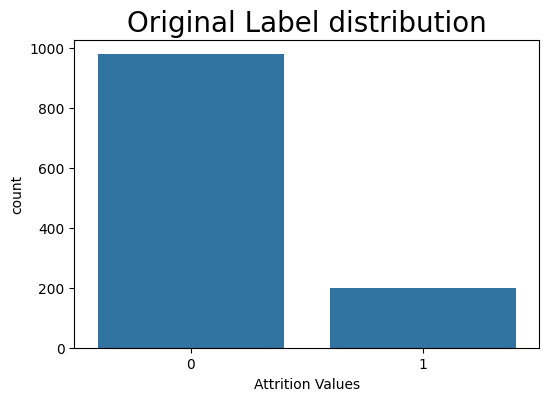

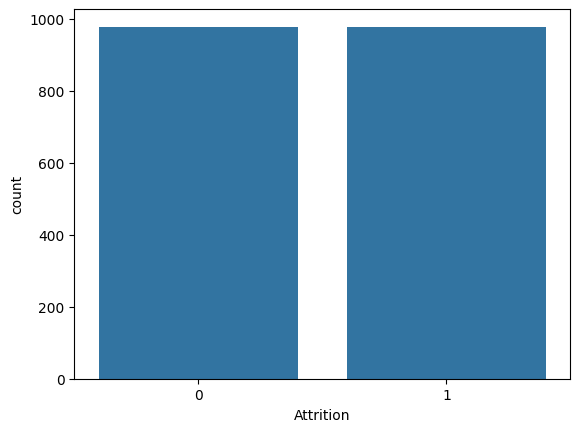

In [24]:

#Splitting of original dataset into a set of features X and a label y
X = df_pp_balancing.drop('Attrition', axis=1)
y = df_pp_balancing['Attrition']


#Get the index number of the categorical feature which will later be used as part of SMOTENC
categorical_indices = X.select_dtypes(include=['category']).columns
categorical_indices = [X.columns.get_loc(col) for col in categorical_indices]




#Split data into random train and test subsets
# X and Y are the inputs i.e. the dataframe and series.
#Industry standard proportion of 20% test size was opted for.
#Permitting a random state = 42 (i.e. an int) controls shuffling and permits reproducability.
#X_train, y_train are used for training and fitting model
#X_test, y_test are used for testing and fitting model

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Smoten applied only on training data
#Parameter passing an array of indices specifying the categorical features.
#Rnadom state = 42 controlling random state of algo
#A default overration was opted for this means that the ratio of minority to majority class must be 1
smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)


#Resampling of dataset.
#Para 1 = data which has to be sampled
#Para 2 = label for each sample in Para 1
#Returns) X_train_reasampled, array with re-sampled data
#Returns Y_train_reasampled, label of x_train_resampled
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)


##Sanity Checking that SMOTENC Balanced attrition properly.
# Plot countplot for original training data
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x=y_train)
ax.set_xlabel("Attrition Values")
ax.set_title("Original Label distribution", fontsize=20, fontweight='medium')
plt.show()

# Plot countplot for resampled training data

sns.countplot(x=y_train_resampled)
ax.set_xlabel("Attrition Values")
ax.set_title("Label distribution post SMOTENC", fontsize=20, fontweight='medium')
plt.show()



Evaluating Class Balancing (SMOTENC) through a baseline RF model:

Strategy 1: Evaluation of RF model using unbalanced Data

Strategy 2: Evaluation of RF Model using SMOTENC Balanced Data

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       255
           1       0.42      0.13      0.20        39

    accuracy                           0.86       294
   macro avg       0.65      0.55      0.56       294
weighted avg       0.82      0.86      0.83       294



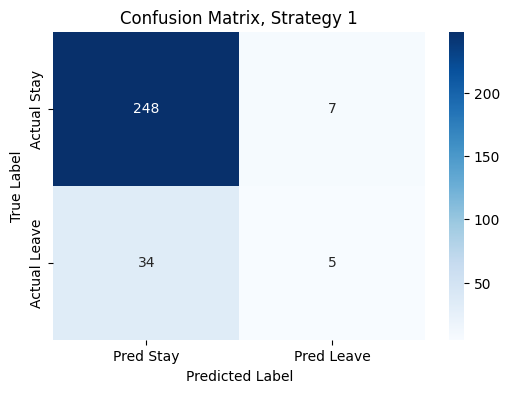

y_test distribution: Attrition
0    255
1     39
Name: count, dtype: int64
Unique values in y_test: [0, 1]
Categories (2, int64): [0, 1]
Length: 294


In [25]:
#STRATEGY 1 - Evaluation of RF Model using unbalanced Data


#numer of tress in forest left at default = 100
# random state, randomness of bootstrapping of samples when tree building
rf_classifier_s1 = RandomForestClassifier(n_estimators=100, random_state=42)



#building forest of tree from the training set (x, y), note resamples data is being used
rf_classifier_s1.fit(X_train, y_train)

#Measures time after training



#Predicted Labels for Test Data
# prediciton is based on vote by trees weighted by their proabability estimates
# Parameter: input samples
# Output: Predicted clases
y_pred_s1 = rf_classifier_s1.predict(X_test)


## Performance Measures

#Building of text report showing main classification metrics
# Parameters, Para 1 = correct values, para 2 = predicted values
# Returns summary of precision, recalls
print(classification_report(y_test, y_pred_s1))

#Evaluated the accuracy of a classification by computing confusion matrix
# para 1 = ground truth
# para 2 = estimated targets
cm = confusion_matrix(y_test, y_pred_s1)


plt.figure(figsize=(6,4))
# Para 1 = Data set
# annot = true displays numeric values in cell
# cmap colors = select color
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred Stay", "Pred Leave"],
    yticklabels=["Actual Stay", "Actual Leave"]
)

#Addition of title and Labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix, Strategy 1")
plt.show()


print("y_test distribution:", y_test.value_counts())
print("Unique values in y_test:", y_test.unique())
print("Length:", len(y_test))


              precision    recall  f1-score   support

           0       0.89      0.91      0.90       255
           1       0.33      0.28      0.31        39

    accuracy                           0.83       294
   macro avg       0.61      0.60      0.60       294
weighted avg       0.82      0.83      0.82       294



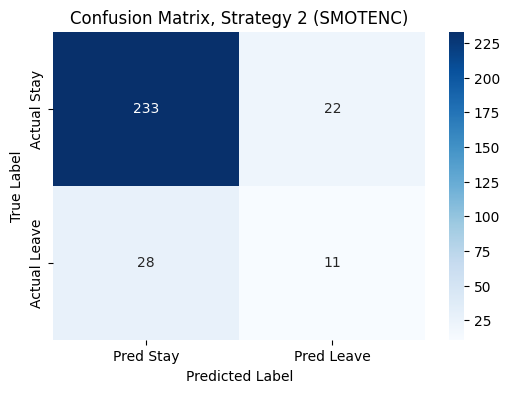

Training time: 0.8676 seconds
y_test distribution: Attrition
0    255
1     39
Name: count, dtype: int64
Unique values in y_test: [0, 1]
Categories (2, int64): [0, 1]
Length: 294


In [26]:
#STRATEGY 2 - Evaluaton of RF Model using SMOTENC Balanced Data

#numer of tress in forest left at default = 100
# random state, randomness of bootstrapping of samples when tree building
rf_classifier_s = RandomForestClassifier(n_estimators=100, random_state=42)

#Measures time before building random forest
start = time.perf_counter()

#building forest of tree from the training set (x, y), note resamples data is being used
rf_classifier_s.fit(X_train_resampled, y_train_resampled)

#Measures time after training
end = time.perf_counter()


#Predicted Labels for Test Data
# prediciton is based on vote by trees weighted by their proabability estimates
# Parameter: input samples
# Output: Predicted clases
y_pred_s = rf_classifier_s.predict(X_test)



## Performance Measures

#Building of text report showing main classification metrics
# Parameters, Para 1 = correct values, para 2 = predicted values
# Returns summary of precision, recalls
print(classification_report(y_test, y_pred_s))

#Evaluated the accuracy of a classification by computing confusion matrix
# para 1 = ground truth
# para 2 = estimated targets
cm_s = confusion_matrix(y_test, y_pred_s)



plt.figure(figsize=(6,4))
# Para 1 = Data set
# annot = true displays numeric values in cell
# cmap colors = select color
sns.heatmap(
    cm_s, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred Stay", "Pred Leave"],
    yticklabels=["Actual Stay", "Actual Leave"]
)

#Addition of title and Labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix, Strategy 2 (SMOTENC)")
plt.show()

#Estimation of training effort
print(f"Training time: {end - start:0.4f} seconds")

print("y_test distribution:", y_test.value_counts())
print("Unique values in y_test:", y_test.unique())
print("Length:", len(y_test))


Dissertation Reference, Chapter 5.2.4 Feature Selection.



Prepping Data for Symetrical Uncertaintiy.

In [27]:
#Initialising KBinsDiscretizer
#Setting number of bins to 5
#encode to ordinal, returns bin identifer encoded as an integer value, this is important as later symetrical uncertainty must be computed
#strategy to quantile to compensate for skewed data, all bins in each feature have same number of points.
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

#Establishing dataframe which will be used for symetrical uncertainty.

#This dataframe will in essence only have categorical data
df_pp_binned = df_pp.copy()



#Creation of list, Features to bin (numerical features which must be placed in discrete categories)
features_to_bin = ['DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
                   'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

#Applying binning to all features within df_pp_binned having a feature name in line those feature names stored in features_to_bin
#note returns a ndnarray hence feature columns= labels are lost
binned = discretizer.fit_transform(df_pp_binned[features_to_bin])

#preparing a loop to discriminate between original numerical features and numerical features which have been categorised (binned)

#Empty list to store new feature names
features_renamed = []

#iterate through list and add 'binned' to each string
for feature in features_to_bin:
  #Creation of new string
  feature_renamed = feature + '_binned'
  #Addition of new string to list
  features_renamed.append(feature_renamed)

#Creation of dataframe called df_binned which has all binned features with feature labels.
#Covnerting datatype to int as opposed to float to ensure robustness in symetrical uncertainty calculation
df_binned_only = pd.DataFrame(data = binned, columns = features_renamed).astype(int)


# The two dataframes are merged column wise into the dataframe called df_pp_binned
#ignore_index was left as the default false, else data would have been added both row and column wise.
#I.e. columns (related to df_binned_only) added but with new indexes (i.e not sharing same rows as previous dataframe)
df_pp_binned = pd.concat([df_pp_binned, df_binned_only], axis=1)


#List with feature labels to drop. Since the dataframe df_pp_binned has duplicated data example it has feature 'DistanceFromHome' and 'DistanceFromHome_binned', we do need the features that have not been binned
features_to_drop = ['DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
                   'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


#Dropping non-binned features.
df_pp_binned = df_pp_binned.drop(features_to_drop, axis='columns')

#Prior to considering symetrical uncertainty ensuring that the features have an appropriote datatype
#For the sake of consistency all features where given a datatype of int.
print(df_pp_binned.dtypes)

#factorize was utilised to encode object features as enumerated types

#Enumerating Attrition
codes, uniques = pd.factorize(df_pp_binned['Attrition'])
df_pp_binned['Attrition'] = codes

#Enumerating BusinessTravel
codes, uniques = pd.factorize(df_pp_binned['BusinessTravel'])
df_pp_binned['BusinessTravel'] = codes

#Enumerating Department
codes, uniques = pd.factorize(df_pp_binned['Department'])
df_pp_binned['Department'] = codes

#Enumerating EducationField
codes, uniques = pd.factorize(df_pp_binned['EducationField'])
df_pp_binned['EducationField'] = codes

#Enumerating JobRole
codes, uniques = pd.factorize(df_pp_binned['JobRole'])
df_pp_binned['JobRole'] = codes

#Enumerating OverTime
codes, uniques = pd.factorize(df_pp_binned['OverTime'])
df_pp_binned['OverTime'] = codes


#Confirming uniformity of datatypes
print(df_pp_binned.dtypes)

#Sanity checking that features are in a reasonable number of categories prior to running symetrical uncertainty
#iterates over each column in dataframe and prints feature label and number of unique categories
for col in df_pp_binned.columns:
    print(col, df_pp_binned[col].nunique())

Attrition                         object
BusinessTravel                    object
Department                        object
Education                          int64
EducationField                    object
JobInvolvement                     int64
JobLevel                           int64
JobRole                           object
OverTime                          object
PerformanceRating                  int64
StockOptionLevel                   int64
DistanceFromHome_binned            int64
MonthlyIncome_binned               int64
NumCompaniesWorked_binned          int64
PercentSalaryHike_binned           int64
TotalWorkingYears_binned           int64
TrainingTimesLastYear_binned       int64
YearsAtCompany_binned              int64
YearsInCurrentRole_binned          int64
YearsSinceLastPromotion_binned     int64
YearsWithCurrManager_binned        int64
dtype: object
Attrition                         int64
BusinessTravel                    int64
Department                        int64
Educa

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 8 are removed. Consider decreasing the number of bins.
  warnings.warn(


Establishing and running Symetrical Uncertainty Function

In [28]:


# shannon_entophy, the denominator of symetric uncertainty
# Parameter: ndarray
# returns: entophy value for that feature passed in the ndarray in bits (log2)
def shannon_entrophy(z):
  #bincount computes the frequency of each unique value in the target
  #counts passed to entrophy function along with base of 2
  shan_ent = entropy(np.bincount(z), base=2)
  return shan_ent



# mutual_information, the numerator of symetric uncertainty
#Parameters array like vectors having an equal number of samples
#by design answer is a non-negative vlaue measured in nats, the last line converts the answers to bits
def mutual_information(x, y):
  mi = mutual_info_score(x, y)
  mi = mi/np.log(2)
  return mi


#symetrical uncertainty calling function mutual_information and shannon_entophy
def symmetrical_uncertainty(x, y):
    H_x = shannon_entrophy(x)
    H_y = shannon_entrophy(y)
    MI = mutual_information(x, y)

    SU = 2 * MI / (H_x + H_y)

    return SU


#all feature labels stored in feature_labels
feature_labels = df_pp_binned.columns

#Creation of dataframe su_matrix this is where the symmetrical uncertainty results shall be stored
#the index shall utilise the feature_labels
#columns name shall also utilise feature_labels hence creating a matrix
su_matrix = pd.DataFrame(index=feature_labels, columns = feature_labels, dtype=float)

#Iterating across each feature and ensuring every feature is compared with every other feature

for f1 in feature_labels:
  for f2 in feature_labels:
    su_matrix.loc[f1,f2] = symmetrical_uncertainty(df_pp_binned[f1].values, df_pp_binned[f2].values)




# Export SU_MATRIX to Excel
su_matrix.to_excel('su_matrix.xlsx', sheet_name='Sheet1', index=False)






Display of Symetrical Uncertainity Results in the form of a paretho graph

                                SU_scores  Cumulative_Percentage
OverTime                         0.053376              18.545468
JobLevel                         0.027854              28.223241
StockOptionLevel                 0.026641              37.479775
JobRole                          0.024480              45.985410
YearsAtCompany_binned            0.022378              53.760759
MonthlyIncome_binned             0.021255              61.145749
TotalWorkingYears_binned         0.021038              68.455226
YearsWithCurrManager_binned      0.020480              75.571108
YearsInCurrentRole_binned        0.017277              81.573897
BusinessTravel                   0.013114              86.130197
JobInvolvement                   0.011712              90.199516
NumCompaniesWorked_binned        0.006492              92.455114
Department                       0.005867              94.493460
EducationField                   0.005443              96.384458
DistanceFromHome_binned  

/tmp/ipykernel_1797/233227443.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(paretho_df.index, rotation=45, ha='right')


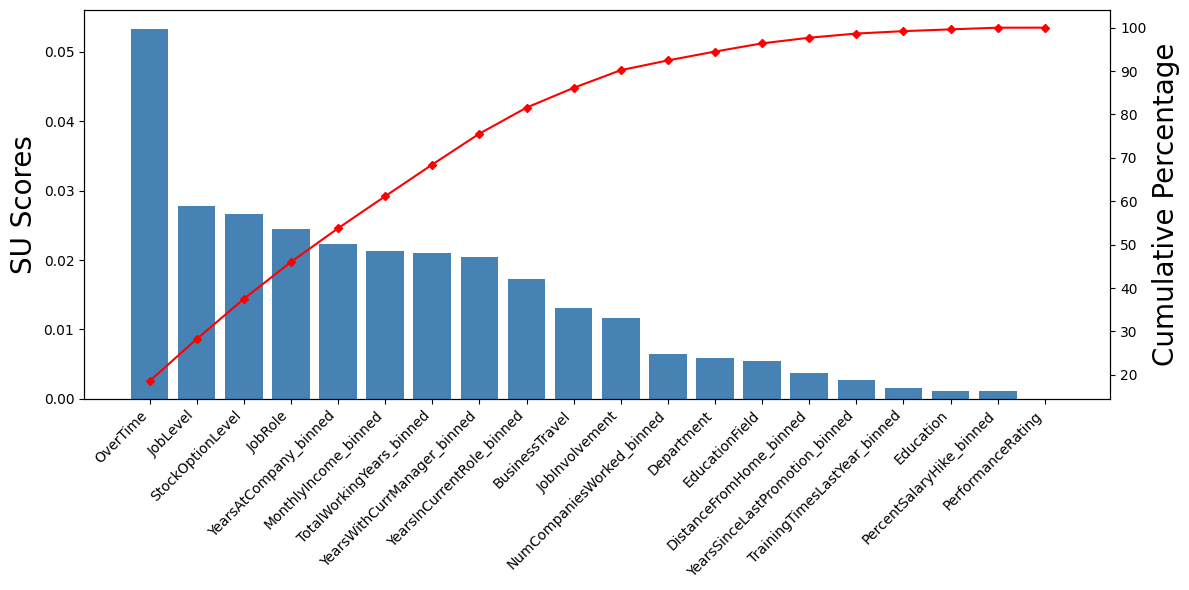

In [29]:
#Creation of Paretho Graph
#Creation of Dataframe focusing just on how features interaction with attrition
paretho_df = su_matrix['Attrition'].sort_values(ascending=False).to_frame()

#Labelling of column
paretho_df.columns = ['SU_scores']

#dropping row by index
paretho_df = paretho_df.drop(index='Attrition')

#Adding a new column called cumulative percentage
paretho_df['Cumulative_Percentage'] = paretho_df['SU_scores'].cumsum()/paretho_df['SU_scores'].sum() * 100

print(paretho_df)



#Plot aesthetics
color1 = 'steelblue'
color2 = 'red'
line_size = 4

#bar plot
fig, ax = plt.subplots(figsize = (12,6))
ax.bar(paretho_df.index, paretho_df['SU_scores'], color=color1)
ax.set_ylabel('SU Scores', fontsize = 20, fontweight = 'medium')


#cumulative percentage
ax2 = ax.twinx()
ax2.plot(paretho_df.index, paretho_df['Cumulative_Percentage'], color=color2, marker='D', ms=line_size)
ax2.set_ylabel('Cumulative Percentage', fontsize = 20, fontweight = 'medium')

ax.set_xticklabels(paretho_df.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


Strategy 3: Reduced Feature Set and Balanced (SMOTENC)

Reducing dataset

In [30]:
#Removing features below Paretho Threhold these will be used to help understand the effect of feature reduction.
X_train_reduced = X_train_resampled.drop(columns=['PerformanceRating', 'PercentSalaryHike', 'Education', 'TrainingTimesLastYear', 'YearsSinceLastPromotion',
                                                  'DistanceFromHome', 'EducationField_1', 'EducationField_2', 'EducationField_3', 'EducationField_4', 'EducationField_5', 'EducationField_6', 'Department_1',
                                                  'Department_2', 'Department_3', 'NumCompaniesWorked'])

X_test_reduced = X_test.drop(columns=['PerformanceRating', 'PercentSalaryHike', 'Education', 'TrainingTimesLastYear', 'YearsSinceLastPromotion',
                                                  'DistanceFromHome', 'EducationField_1', 'EducationField_2', 'EducationField_3', 'EducationField_4', 'EducationField_5', 'EducationField_6', 'Department_1',
                                                  'Department_2', 'Department_3', 'NumCompaniesWorked'])

In [31]:
#Sanity checking cleanup

#print(X_train_reduced)
#print(X_test_reduced)

Training baseline RF model with reduced dataset and corresponding classification report.

In [32]:
#Removing features below Paretho Threhold these will be used to help understand the effect of feature reduction.


y_train_s3 = y_train_resampled
y_test_s3 = y_test



rf_classifierRed = RandomForestClassifier(n_estimators=100, random_state=42)
start = time.perf_counter()
rf_classifierRed.fit(X_train_reduced, y_train_s3)
end = time.perf_counter()

#Predicted Labels for Test Data
y_pred_Red = rf_classifierRed.predict(X_test_reduced)


print(classification_report(y_test_s3, y_pred_Red))


print(f"Training time: {end - start:0.4f} seconds")

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       255
           1       0.30      0.33      0.32        39

    accuracy                           0.81       294
   macro avg       0.60      0.61      0.60       294
weighted avg       0.82      0.81      0.81       294

Training time: 0.5941 seconds


Dissertation Reference, Chapter 5.2.5 Knowledge Graph Construction

new dataframe called df_pre_graph shall be created to cater for creation of graph db.

In [33]:
#Checking present features to permit dropping of those eliminating by data description results and feature selection excercise
print(df_RAW.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object', name='Column Labels')


In [34]:

df_pre_graph = df_RAW .drop(['Age', 'DailyRate', 'DailyRate', 'EmployeeCount', 'HourlyRate', 'MonthlyRate', 'Over18', 'StandardHours', 'Gender', 'PerformanceRating', 'PercentSalaryHike',
                            'Education', 'TrainingTimesLastYear', 'RelationshipSatisfaction', 'YearsSinceLastPromotion', 'DistanceFromHome', 'EducationField',
                            'NumCompaniesWorked', 'JobInvolvement',  'EmployeeCount', 'HourlyRate', 'MonthlyRate', 'Over18', 'StandardHours', 'MaritalStatus',
                             'BusinessTravel', 'Department', 'EnvironmentSatisfaction', 'JobSatisfaction',
                             'WorkLifeBalance'], axis=1)

print(df_pre_graph.columns)

#Checking if jobrole and joblevel are tied together
#This would directly aid the development of the graph database design shown in Table 5.5 Node Properties
print(df_pre_graph.groupby("JobRole")["JobLevel"].nunique())
print(df_pre_graph.groupby("JobRole")["MonthlyIncome"].nunique())
print(df_pre_graph.groupby("JobRole")["StockOptionLevel"].nunique())


print(df_pre_graph.dtypes)

Index(['Attrition', 'EmployeeNumber', 'JobLevel', 'JobRole', 'MonthlyIncome',
       'OverTime', 'StockOptionLevel', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsWithCurrManager'],
      dtype='object', name='Column Labels')
JobRole
Healthcare Representative    3
Human Resources              3
Laboratory Technician        3
Manager                      3
Manufacturing Director       3
Research Director            3
Research Scientist           3
Sales Executive              3
Sales Representative         2
Name: JobLevel, dtype: int64
JobRole
Healthcare Representative    127
Human Resources               52
Laboratory Technician        248
Manager                      102
Manufacturing Director       144
Research Director             80
Research Scientist           274
Sales Executive              318
Sales Representative          82
Name: MonthlyIncome, dtype: int64
JobRole
Healthcare Representative    4
Human Resources              4
Laboratory Technician

In [35]:
#Conversion to String due to requirements of node2vec further downstream
df_pre_graph['EmployeeNumber'] = df_pre_graph['EmployeeNumber'].astype(object)
print(df_pre_graph.dtypes)

Column Labels
Attrition               object
EmployeeNumber          object
JobLevel                 int64
JobRole                 object
MonthlyIncome            int64
OverTime                object
StockOptionLevel         int64
TotalWorkingYears        int64
YearsAtCompany           int64
YearsInCurrentRole       int64
YearsWithCurrManager     int64
dtype: object


Creation and refresh of graph object 'graph'

In [36]:
#Creation of Graph object
URI = "neo4j+s://6e140023.databases.neo4j.io"

AUTH = ("neo4j", "PnTllUl3YMgtsUWA_Jmb5Orz0-2r2DmL8mDq2o3JyUg")

graph = Graph(URI, auth=AUTH)
#Clearing of graph object.

# Commented out since each time all nodes and relationships shall be wipped clean
# graph.delete_all()



Creation of JobRole Node

Commented out as process is time consuming and data has not changed

In [39]:
'''
for jr in df_pre_graph['JobRole'].unique():
  #creation of node object
  #Parmeter 1 = Label, uniue and ordered set of tabs to classify and identify nodes
  #Parameter 2 = Name, data about node
  #return node.
    JR_node = Node("JobRole", name=jr)
    #Merging of node into neo4j database
    #Parameter 1 = subgraph object like a node/ relationship
    #Parameter 2 = Label on which to match any existing nodes
    #Parameter 3 = property keys on which to match any existing nodes
    graph.merge(JR_node, "JobRole", "name")

    #This should create nodes having label department. Each label department nodes should then have their own department name.
'''


'\nfor jr in df_pre_graph[\'JobRole\'].unique():\n  #creation of node object\n  #Parmeter 1 = Label, uniue and ordered set of tabs to classify and identify nodes\n  #Parameter 2 = Name, data about node\n  #return node.\n    JR_node = Node("JobRole", name=jr)\n    #Merging of node into neo4j database\n    #Parameter 1 = subgraph object like a node/ relationship\n    #Parameter 2 = Label on which to match any existing nodes\n    #Parameter 3 = property keys on which to match any existing nodes\n    graph.merge(JR_node, "JobRole", "name")\n\n    #This should create nodes having label department. Each label department nodes should then have their own department name.\n'

Creation of Employee Node

Commented out as process is time consuming and data has not changed


In [40]:

'''
#df_pre_graph = df_pre_graph[:5]
#Iterate over dataframe rows using iterrows. Typically yields the index and the data of the row as a series
#Parameter 1 = stored the index (not used in this case)
#Parameter 2 = stores the data of the row as a series.
for en in df_pre_graph['EmployeeNumber'].unique():

  #Creation of node objects
  #Parameter 1 = new nodes will have label = Employee
  #Parameter 2 = Employee Number, data about node
  #return node
  emp_node = Node("Employee", EmployeeId = int(en))

  #Merging of node into neo4j db
  #Parameter 1 = subgraph object like a node/relationship
  #Parameter 2 = label on which to match any existing nodes
  #Parameter 3 = property key on whih to match any existing nodes a unique key was chosen for employee
  graph.merge(emp_node, "Employee", "EmployeeId")
  '''

'\n#df_pre_graph = df_pre_graph[:5]\n#Iterate over dataframe rows using iterrows. Typically yields the index and the data of the row as a series\n#Parameter 1 = stored the index (not used in this case)\n#Parameter 2 = stores the data of the row as a series.\nfor en in df_pre_graph[\'EmployeeNumber\'].unique():\n\n  #Creation of node objects\n  #Parameter 1 = new nodes will have label = Employee\n  #Parameter 2 = Employee Number, data about node\n  #return node\n  emp_node = Node("Employee", EmployeeId = int(en))\n\n  #Merging of node into neo4j db\n  #Parameter 1 = subgraph object like a node/relationship\n  #Parameter 2 = label on which to match any existing nodes\n  #Parameter 3 = property key on whih to match any existing nodes a unique key was chosen for employee\n  graph.merge(emp_node, "Employee", "EmployeeId")\n  '

Creation of Relationship between node of Label Employee and Node of LabelJobRole

Commented out as process is time consuming and data has not changed

In [41]:

'''
#Iterate over dataframe rows using iterrows. Typically yields the index and the data of the row as a series
#Parameter 1 = stored the index (not used in this case)
#Parameter 2 = stores the data of the row as a series.

for i, series in df_pre_graph.iterrows():

  # Matches nodes with a specific label from graph object.
  #Match
  # Parameter 1 = node labels to match
  # Properties - set of property keys and values to match
  # Returns node match instances
  # note first() evaluates the match and returns the first node match or none, if no matching ndoes are found
  employee_node = graph.nodes.match("Employee", EmployeeId=int(series['EmployeeNumber'])).first()
  jobrole_node = graph.nodes.match("JobRole", name=series['JobRole']).first()

  # Creation relationship between Employee and JobRole
  rel = Relationship(employee_node, "OCCUPIES", jobrole_node)
  graph.merge(rel)
  '''

'\n#Iterate over dataframe rows using iterrows. Typically yields the index and the data of the row as a series\n#Parameter 1 = stored the index (not used in this case)\n#Parameter 2 = stores the data of the row as a series.\n\nfor i, series in df_pre_graph.iterrows():\n\n  # Matches nodes with a specific label from graph object.\n  #Match\n  # Parameter 1 = node labels to match\n  # Properties - set of property keys and values to match\n  # Returns node match instances\n  # note first() evaluates the match and returns the first node match or none, if no matching ndoes are found\n  employee_node = graph.nodes.match("Employee", EmployeeId=int(series[\'EmployeeNumber\'])).first()\n  jobrole_node = graph.nodes.match("JobRole", name=series[\'JobRole\']).first()\n\n  # Creation relationship between Employee and JobRole\n  rel = Relationship(employee_node, "OCCUPIES", jobrole_node)\n  graph.merge(rel)\n  '

Creation of Node2Vec Embeddings

In [42]:
#This query will be ran as a cypher query and will give the relational graph structure
# Retrieving all relationships employee's may have, in this case department or jobrole
relationalgraphstructurequery = """
    MATCH (e:Employee)-[r]-(n)
    RETURN e.EmployeeId as EmployeeId, n.name as DeptorJobRoleId
    """

Dissertation Reference, Chapter 5.2.6 Extraction of Graph Features (Node Embeddings)

Creation of graph in networkX format

In [43]:
# graph - refers to the graph database exposed by a neo4j graph db service
#run - general purpose query execution
# parameter - cypher statement
# returns - list of dictionary of vlaues, keyed by field name
result = graph.run(relationalgraphstructurequery).data()

#Sanity Checking
#print(result)
#print(type(result))

#creator dataframe of results
# The 'result' is already a list of dictionaries, which can be directly converted to a DataFrame
graphstructure_df = pd.DataFrame(result)
graphstructure_df.head()

,EmployeeId,DeptorJobRoleId
0,1,Sales Executive
1,2,Research Scientist
2,4,Laboratory Technician
3,5,Research Scientist
4,7,Laboratory Technician


Building of NetworkX Graph

In [44]:
#Creation of empty graph with no nodes and edges
# Note Graph implimenets an undirected  graph.
G = nx.Graph()

# Sanity checking empty graph has been created.
#Returns a node view
#print(G.nodes)
#Return an edge view
#print(G.edges)


# Parameter 1 - edge list representation of a graph
# Parameter 2 - source, column name related to dataframe (source node)
# Parameter 3 - target, column name related to dataframe (target node)
# Returns graph from pandas dataframe containing an edge list
G = nx.from_pandas_edgelist(graphstructure_df, source = 'EmployeeId', target = 'DeptorJobRoleId')

#Confirming results match dataframe

#Default Spring Layout (was not clear thus provided no value)
#nx.draw(G)

# Returns number of nodes in graph
print ("Nodes Number:", G.number_of_nodes())
# Returns the number of edges in graph
print ("Edges Number:", G.number_of_edges())

# Returns edge and node view
print("Edge View:", G.edges())
print("Node View:", G.nodes())

Nodes Number: 1479
Edges Number: 1470
Edge View: [(1, 'Sales Executive'), ('Sales Executive', 35), ('Sales Executive', 52), ('Sales Executive', 56), ('Sales Executive', 60), ('Sales Executive', 62), ('Sales Executive', 68), ('Sales Executive', 72), ('Sales Executive', 74), ('Sales Executive', 81), ('Sales Executive', 91), ('Sales Executive', 100), ('Sales Executive', 106), ('Sales Executive', 118), ('Sales Executive', 120), ('Sales Executive', 121), ('Sales Executive', 125), ('Sales Executive', 128), ('Sales Executive', 129), ('Sales Executive', 131), ('Sales Executive', 142), ('Sales Executive', 152), ('Sales Executive', 154), ('Sales Executive', 160), ('Sales Executive', 163), ('Sales Executive', 174), ('Sales Executive', 175), ('Sales Executive', 176), ('Sales Executive', 182), ('Sales Executive', 183), ('Sales Executive', 195), ('Sales Executive', 204), ('Sales Executive', 207), ('Sales Executive', 215), ('Sales Executive', 228), ('Sales Executive', 230), ('Sales Executive', 240), 

In [45]:
print(graphstructure_df['DeptorJobRoleId'])

sanitycheck = graphstructure_df['DeptorJobRoleId'].unique()
print(sanitycheck)

0                 Sales Executive
1              Research Scientist
2           Laboratory Technician
3              Research Scientist
4           Laboratory Technician
                  ...            
1465        Laboratory Technician
1466    Healthcare Representative
1467       Manufacturing Director
1468              Sales Executive
1469        Laboratory Technician
Name: DeptorJobRoleId, Length: 1470, dtype: object
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']


In [46]:
G = nx.relabel_nodes(G, lambda x: str(x))

Running of Node2Vec

Setting possible Node2Vec Parameters
Note only the winning subset of parameters tables 5.6-5.7 is shown as the run time was otherwise too lengthy when sanity checking code.

In [47]:

#Simple configuration list which shall be used to store the range of parameter values
node2vecpara = []


#Generating a list with new objects representing range of parameter tunning for Node2Vec
#In essence creating a list of dictionaries

for p in [1]:
   for q in [0.5]:
    for ds in [16]:
      for wl in [40]:
        for nw in [10]:
          node2vecpara.append({
              "p": p,
              "q": q,
              "ds": ds,
              "wl": wl,
              "nw": nw
          })



print(node2vecpara)

[{'p': 1, 'q': 0.5, 'ds': 16, 'wl': 40, 'nw': 10}]


Embeddings based on parameter ranges

In [48]:
#Creating a dictionary to store embeddings across node2vecpara
embedding_dfs = {}


#Loops through each list thus exposing a different dictionary each loop with unique q, p values
# Ultimately we create various df have different embeddings based on different parameters
for para in node2vecpara:
    p  = para["p"]
    q  = para["q"]
    NWPN = para["nw"]
    LWPN = para["wl"]
    DS = para["ds"]


    #Sanity checking position of loop
    print(f"Running parameters: p={p}, q={q}, NWPN={NWPN}, LWPN={LWPN}, DS={DS}")


  # Precompute probabilities and generate walks
  # Parameter 1 Graph - node names must be all integers or all strings
  # Dimensions - embedded dimensions
  # Walklength  - number of nodes in each walk
  # p - return hyperparameter
  # q - input hyperarameter


    node2vec = Node2Vec(
        G,
        dimensions=DS,
        walk_length=LWPN,
        num_walks=NWPN,
        p = p,
        q = q,
        workers=1,
        seed=42
    )

    #Train Model - Produce embeddings (i.e vector representation of each node)
    model = node2vec.fit(window=10, min_count=1, seed=42)

      # Only employee nodes are considered i.e. omit department and job role
      # Creation of value pair, key represents the employe ID
      # value would be the embedded vector.
    employee_embeddings = {
        node: model.wv[node]
        for node in model.wv.index_to_key
        if node.isdigit()
    }


    # Confirms vector length using DIM caused mismatches.
    # Grabs only the values of employee_embeddings not the keys which reference an employee
    # iter returns an iterator object in this scanrio an object capable of returning its members one at a time
    # next, Retrieves an items from an iterator a vector for a single employee
    # len number of object items
    vec_dim = len(next(iter(employee_embeddings.values())))




    # Creation of Data Frame for different node2vec parameters
    emb_df = pd.DataFrame(
        #items returns the key value pairs of the dictionary as tuples in a list
        #Node would be the employee ID
        #Vec would be the embedded vector
        #node + vec.tolist is a concatonated list of employee id and its vector
        [[node] + vec.tolist() for node, vec in employee_embeddings.items()],
        #Columns names of dataframe
        columns=["employeeID"] + [f"emb_{i}" for i in range(vec_dim)]
    )

    #print(emb_df)



    # Dynamic naming to create a dictionary with all dataframes
    key = f"emb_p{p}_q{q}_ds{DS}_LWPN{LWPN}_NWPN{NWPN}"

    # Store df's
    embedding_dfs[key] = emb_df

    print(f"Saved {key} with shape {emb_df.shape}")

    #print(type(embedding_dfs))


Running parameters: p=1, q=0.5, NWPN=10, LWPN=40, DS=16


Computing transition probabilities:   0%|          | 0/1479 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:12<00:00,  1.26s/it]


Saved emb_p1_q0.5_ds16_LWPN40_NWPN10 with shape (1470, 17)


Sanity Checking Embedding Keys the total number should tally to 8 and the keys should align towards the parameters.

In [49]:
print(embedding_dfs.keys())

dict_keys(['emb_p1_q0.5_ds16_LWPN40_NWPN10'])


Creation of new dataframe called result which represents the combination  df_pp_balancing and EmployeeNumber.

In [50]:
#This is independent of node2vec embeddings
print(EmployeeNumber)
#note df_pp_balancing contains data that has been cleaned (outliers) and has been encoded both with label and onehot encoding.
#It is ready for SMOTENC
print(df_pp_balancing)

#Joining employee Number with balanced dataset
# Now dataframe result has all info of df_pp_balancing and employeenumber
result = pd.concat([EmployeeNumber, df_pp_balancing], axis=1, join="inner")
print(result)

0          1
1          2
2          4
3          5
4          7
        ... 
1465    2061
1466    2062
1467    2064
1468    2065
1469    2068
Name: EmployeeNumber, Length: 1470, dtype: int64
     Attrition BusinessTravel  DistanceFromHome Education JobInvolvement  \
0            1              3                 1         2              3   
1            0              2                 8         1              2   
2            1              3                 2         2              2   
3            0              2                 3         4              3   
4            0              3                 2         1              3   
...        ...            ...               ...       ...            ...   
1465         0              2                23         2              4   
1466         0              3                 6         1              2   
1467         0              3                 4         3              4   
1468         0              2                 2 

Checking which features correspond to which datatypes.

In [51]:
print(df_pp_balancing.dtypes)

Attrition                  category
BusinessTravel             category
DistanceFromHome              int64
Education                  category
JobInvolvement             category
JobLevel                   category
MonthlyIncome                 int64
NumCompaniesWorked            int64
PercentSalaryHike             int64
PerformanceRating          category
StockOptionLevel           category
TotalWorkingYears             int64
TrainingTimesLastYear         int64
YearsAtCompany                int64
YearsInCurrentRole            int64
YearsSinceLastPromotion       int64
YearsWithCurrManager          int64
Department_1               category
Department_2               category
Department_3               category
EducationField_1           category
EducationField_2           category
EducationField_3           category
EducationField_4           category
EducationField_5           category
EducationField_6           category
JobRole_1                  category
JobRole_2                  c

Joining of result dataframe with embeddings (iter_df_pq) into a dataframe called result_embedding

Using Smotenc to balance dataset.

In [52]:
for key, value in embedding_dfs.items():
    print(key)
    iter_df_pq = embedding_dfs.get(key)


    # Convert 'EmployeeNumber' in 'result' to object type to match 'employeeID' in 'iter_df_pq' for joining
    result['EmployeeNumber'] = result['EmployeeNumber'].astype(str)
    iter_df_pq['employeeID'] = iter_df_pq['employeeID'].astype(str)

    result['EmployeeNumber'] = result['EmployeeNumber'].str.strip()
    iter_df_pq['employeeID'] = iter_df_pq['employeeID'].str.strip()

    # Use the .join() method of the DataFrame to merge them
    result_embedding = result.join(iter_df_pq.set_index('employeeID'), on='EmployeeNumber', how='left')
    #print(result_embedding)



    #Splitting of original dataset into a set of features X and a label y
    X = result_embedding.drop(['Attrition', 'EmployeeNumber'], axis=1)
    y = result_embedding['Attrition']

    #Get the index number of the categorical feature which will later be used as part of SMOTENC
    categorical_indices = X.select_dtypes(include=['category']).columns
    categorical_indices = [X.columns.get_loc(col) for col in categorical_indices]



    #Split data into random train and test subsets
    # X and Y are the inputs i.e. the dataframe and series.
    #Industry standard proportion of 20% test size was opted for.
    #Permitting a random state = 42 (i.e. an int) controls shuffling and permits reproducability.
    #X_train, y_train are used for training and fitting model
    #X_test, y_test are used for testing and fitting model

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    #Smoten applied only on training data
    #Parameter passing an array of indices specifying the categorical features.
    #Rnadom state = 42 controlling random state of algo
    #A default overration was opted for this means that the ratio of minority to majority class must be 1
    smote_nc = SMOTENC(
        categorical_features=categorical_indices,
        random_state=42
    )


    #Resampling of dataset.
    #Para 1 = data which has to be sampled
    #Para 2 = label for each sample in Para 1
    #Returns X_train_reasampled, array with re-sampled data
    #Returns Y_train_reasampled, label of x_train_resampled
    X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

    #numer of tress in forest left at default = 100
    # random state, randomness of bootstrapping of samples when tree building
    rf_classifier_i1 = RandomForestClassifier(n_estimators=100, random_state=42)



    #building forest of tree from the training set (x, y), note resamples data is being used
    rf_classifier_i1.fit(X_train_resampled, y_train_resampled)

    #Measures time after training



    #Predicted Labels for Test Data
    # prediciton is based on vote by trees weighted by their proabability estimates
    # Parameter: input samples
    # Output: Predicted clases
    y_pred_s1 = rf_classifier_i1.predict(X_test)


    ## Performance Measures

    #Building of text report showing main classification metrics
    # Parameters, Para 1 = correct values, para 2 = predicted values
    # Returns summary of precision, recalls
    print(classification_report(y_test, y_pred_s1))

    #Evaluated the accuracy of a classification by computing confusion matrix
    # para 1 = ground truth
    # para 2 = estimated targets
    cm = confusion_matrix(y_test, y_pred_s1)









emb_p1_q0.5_ds16_LWPN40_NWPN10
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       255
           1       0.38      0.28      0.32        39

    accuracy                           0.84       294
   macro avg       0.64      0.61      0.62       294
weighted avg       0.83      0.84      0.83       294



Dissertation Reference, **Chapter 5.2.8** Building and Training of Model - part related to data embeddings

Ensuring that the correct result embedding is chosen.
Given the embedding emb_p1_q0.5_ds16_LWPN40_NWPN10 performed best the result embedding_dataframe must be re-created with this.  Table 5.9

In [53]:
for key, value in embedding_dfs.items():

  #This is the identified best embedded vector
    if (key == 'emb_p1_q0.5_ds16_LWPN40_NWPN10'):
      print(key)
      iter_df_pq = embedding_dfs.get(key)


      # Convert 'EmployeeNumber' in 'result' to object type to match 'employeeID' in 'iter_df_pq' for joining
      result['EmployeeNumber'] = result['EmployeeNumber'].astype(str)
      iter_df_pq['employeeID'] = iter_df_pq['employeeID'].astype(str)

      result['EmployeeNumber'] = result['EmployeeNumber'].str.strip()
      iter_df_pq['employeeID'] = iter_df_pq['employeeID'].str.strip()

      # Use the .join() method of the DataFrame to merge them
      result_embedding = result.join(iter_df_pq.set_index('employeeID'), on='EmployeeNumber', how='left')
      #print(result_embedding)


emb_p1_q0.5_ds16_LWPN40_NWPN10


In [54]:
   #Splitting of original dataset into a set of features X and a label y
x = result_embedding.drop(['Attrition', 'EmployeeNumber'], axis=1)
y = result_embedding['Attrition']

#Setting a range of possible parameter values for Random Forest's Parameters
#Note the range was done as per table 5.9 but reduced as per table 5.10 to reduce operation time when testing.
param_grid = {
    'n_estimators': [100],
    'max_samples': [0.1],
    'max_features': [3],
    'bootstrap': [True],

}

#Technique to evaluate a model and uses stratification which permits original distirbution of each class across folds
#This helps ensure that both training and test set provides an accurate representation of a datasets proportions
#Provides train test indices to split data in train/test sets
#Parameter 1 = number of folds
#Parameter 3 = affects ordering of the indices which controls randomness of each fold for each class
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#Declare and initialise the best recall score to 0
best_score_recall = 0
#Identify the best hyperparameters associated with the best score.
best_params = None


In [55]:
#Iterate through parameter grid

for n_estimators in param_grid['n_estimators']:
    for max_samples in param_grid['max_samples']:
        for max_features in param_grid['max_features']:
            for bootstrap in param_grid['bootstrap']:

                #Empty list to store fold reports
                fold_reports = []



                #Split dataset into stratified train, test indices
                #Provides train/test indices to split data in train/test sets.
                for train_index, test_index in skf.split(x, y):


                    categorical_indices = x.select_dtypes(include=['category']).columns
                    categorical_indices = [x.columns.get_loc(col) for col in categorical_indices]

                    #Features for training and testing
                    X_train_fold = X.iloc[train_index]
                    X_test_fold = X.iloc[test_index]

                    #Labels for Training and Testing
                    Y_train_fold = y.iloc[train_index]
                    Y_test_fold = y.iloc[test_index]

                    #Application SMOTENC on training fold only
                    smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
                    X_train_res, y_train_res = smote.fit_resample(X_train_fold, Y_train_fold)

                # Train Random Forest
                    model = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_samples=max_samples,
                        max_features=max_features,
                        bootstrap=bootstrap,
                        random_state=42
                    )
                    model.fit(X_train_res, y_train_res)

                    # Predict on validation fold
                    y_pred = model.predict(X_test_fold)

                    # builds a text showing main classification metrics
                    #Para 1 = ground truth
                    #Para 2 = estimated targets returned by classifier
                    #Para 3 = return output of resutls as a dictionary as opposed to a report
                    #para 4 = sets the values to return when theire is a zero division
                    report = classification_report(
                        Y_test_fold,
                        y_pred,
                        output_dict=True,
                        zero_division=0
                    )


                    #Adds fold reports into a list
                    fold_reports.append(report)



                #mean report dictionary to hold average metrics
                mean_report = {}

                #looping through
                # labels like 0, 1, accuracy, macroaverage, weighted avg inside a particular report
                # This is just being used to obtain the labels since the labels across all folds must be the same
                for label in fold_reports[0].keys():




                    #Check if a particular label (example 0, 1, macro avg etc..) the type is of type dictionary using the 1st
                    #fold as an example
                    if isinstance(fold_reports[0][label], dict):


                        #To aligns towrds the nested classification reports

                        mean_report[label] = {}

                        #looping through metrics inside a label
                        for metric in fold_reports[0][label].keys():
                           #mean metrics across folds
                            mean_report[label][metric] = np.mean(
                                #iterate through folds, labels and metrics
                                [rep[label][metric] for rep in fold_reports]
                            )
                    #Consider accuracy
                    else:
                      #sums similar metrics across every fold report.
                        mean_report[label] = np.mean(
                            [rep[label] for rep in fold_reports]
                        )

                # Convert to DataFrame for readability
                mean_report_df = pd.DataFrame(mean_report).T


                # Output


                print("Parameters:")
                print({
                    'n_estimators': n_estimators,
                    'max_samples': max_samples,
                    'max_features': max_features,
                    'bootstrap': bootstrap
                })
                print("\nMean Classification Report (CV):")
                print(mean_report_df.round(2))

Parameters:
{'n_estimators': 100, 'max_samples': 0.1, 'max_features': 3, 'bootstrap': True}

Mean Classification Report (CV):
              precision  recall  f1-score  support
0                  0.89    0.89      0.89   123.30
1                  0.44    0.43      0.43    23.70
accuracy           0.82    0.82      0.82     0.82
macro avg          0.67    0.66      0.66   147.00
weighted avg       0.82    0.82      0.82   147.00


Dissertation Reference, Chapter 5.2.8 Building and Training of Model - Tabular Data, Table 5.10

In [56]:
Employeenumber2 = EmployeeNumber

df_employees = pd.DataFrame(Employeenumber2)
#print(df_employees)

#Combine on the index
#print(df_pp_balancing)
#print(df_employees)

df_combo = df_pp_balancing.join(df_employees)

#print(df_combo)

#preperation of dataset
#note this dataset is unbalanced
Xf1 = df_combo.drop(['Attrition', 'EmployeeNumber'], axis=1)
yf2 = df_combo['Attrition']


#Setting a range of possible parameter values for Random Forest's Parameters
#Only the values as per table 5.11 where inserted in actual fact this was initially done with values as per Table 5.9
param_grid = {
    'n_estimators': [500],
    'max_samples': [0.1],
    'max_features': [3],
    'bootstrap': [True],

}

#Technique to evaluate a model and uses stratification which permits original distirbution of each class across folds
#This helps ensure that both training and test set provides an accurate representation of a datasets proportions
#Provides train test indices to split data in train/test sets
#Parameter 1 = number of folds
#Parameter 2 =
#Parameter 3 = affects ordering of the indices which controls randomness of each fold for each class
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#Declare and initialise the best recall score to 0
best_score_recall = 0
#Identify the best hyperparameters associated with the best score.
best_params = None

#Iterate through parameter grid

for n_estimators in param_grid['n_estimators']:
    for max_samples in param_grid['max_samples']:
        for max_features in param_grid['max_features']:
            for bootstrap in param_grid['bootstrap']:

                #Empty list to store fold reports
                fold_reports = []



                #Split dataset into stratified train, test indices
                for train_index, test_index in skf.split(Xf1, yf2):



                    #Features for training and testing
                    X_train_fold = Xf1.iloc[train_index]
                    X_test_fold = Xf1.iloc[test_index]

                    #Labels for Training and Testing
                    Y_train_fold = yf2.iloc[train_index]
                    Y_test_fold = yf2.iloc[test_index]

                    #Application SMOTENC on training fold only
                    smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
                    X_train_res, y_train_res = smote.fit_resample(X_train_fold, Y_train_fold)

                # Train Random Forest
                    model = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_samples=max_samples,
                        max_features=max_features,
                        bootstrap=bootstrap,
                        random_state=42
                    )
                    model.fit(X_train_res, y_train_res)

                    # Predict on validation fold
                    y_pred = model.predict(X_test_fold)

                    # builds a text showing main classification metrics
                    #Para 1 = ground truth
                    #Para 2 = estimated targets returned by classifier
                    #Para 3 = return output of resutls as a dictionary as opposed to a report
                    #para 4 = sets the values to return when theire is a zero division
                    report = classification_report(
                        Y_test_fold,
                        y_pred,
                        output_dict=True,
                        zero_division=0
                    )


                        #Adds fold reports into a list
                    fold_reports.append(report)

             #mean report dictionary to hold average metrics
                mean_report = {}

                 #looping through
                # labels like 0, 1, accuracy, macroaverage, weighted avg inside a particular report
                # This is just being used to obtain the labels since the labels across all folds must be the same
                for label in fold_reports[0].keys():
                    #Check if a particular label (example 0, 1, macro avg etc..) the type is of type dictionary using the 1st
                    #fold as an example

                    if isinstance(fold_reports[0][label], dict):

                           #To aligns towrds the nested classification reports
                        mean_report[label] = {}
                          #looping through metrics inside a label
                        for metric in fold_reports[0][label].keys():
                              #mean metrics across folds
                            mean_report[label][metric] = np.mean(
                                 #iterate through folds, labels and metrics
                                 [rep[label][metric] for rep in fold_reports]
                            )
                       #Consider accuracy
                    else:
                          #sums similar metrics across every fold report.
                        mean_report[label] = np.mean(
                            [rep[label] for rep in fold_reports]
                        )

     # Convert to DataFrame for readability
                mean_report_df = pd.DataFrame(mean_report).T



                print("Parameters:")
                print({
                    'n_estimators': n_estimators,
                    'max_samples': max_samples,
                    'max_features': max_features,
                    'bootstrap': bootstrap
                })
                print("\nMean Classification Report (CV):")
                print(mean_report_df.round(3))







Parameters:
{'n_estimators': 500, 'max_samples': 0.1, 'max_features': 3, 'bootstrap': True}

Mean Classification Report (CV):
              precision  recall  f1-score  support
0                 0.905   0.860     0.882  123.300
1                 0.428   0.532     0.471   23.700
accuracy          0.807   0.807     0.807    0.807
macro avg         0.667   0.696     0.676  147.000
weighted avg      0.828   0.807     0.815  147.000


Dissertation Reference, Chapter 5.2.7 - Extraction of Graph Features (Topological Features)

In [57]:
Employeenumber2 = EmployeeNumber
#Employee data frame having the original index alongside employee number
df_employees = pd.DataFrame(Employeenumber2)
print(df_employees)

      EmployeeNumber
0                  1
1                  2
2                  4
3                  5
4                  7
...              ...
1465            2061
1466            2062
1467            2064
1468            2065
1469            2068

[1470 rows x 1 columns]


In [58]:
print(G)

Graph with 1479 nodes and 1470 edges


In [59]:
from collections import Counter

In [60]:
#Computes harmonic centrality for nodes
#Parameter G represents a networkx Graph
#Parameter nbunch by default, considers all nodes in G. Container of nodes for which harmonic centrality values are calculated.
#Parameter distance, optional default = None
# Return dictionary of nodes with harmonic centrality as the value
harmonic = nx.harmonic_centrality(G)

#Sanity Checking Results
print(harmonic)

unique_values = set(harmonic.values())
print(len(unique_values))

counts = Counter(harmonic.values())
print(counts)

{'882': 130.0, '1813': 146.5, '381': 51.5, '2041': 163.5, '42': 42.0, '339': 73.0, '363': 51.5, '806': 130.0, '1163': 163.5, '283': 163.5, '1947': 146.5, '405': 130.0, '1937': 146.5, '274': 73.0, '614': 42.0, '137': 130.0, '716': 130.0, '661': 40.5, '783': 42.0, '1834': 146.5, '329': 51.5, '514': 146.5, '605': 73.0, '216': 42.0, '264': 51.5, '133': 26.5, '584': 130.0, '1273': 42.0, '558': 51.5, '1809': 73.0, '683': 146.5, '1572': 73.0, '448': 130.0, '933': 146.5, '359': 130.0, '1268': 163.5, '1180': 146.5, '1486': 42.0, '380': 40.5, '813': 130.0, '1447': 130.0, '1240': 163.5, '1628': 73.0, '1749': 163.5, '141': 40.5, '1224': 130.0, '252': 146.5, '1217': 40.5, '1865': 26.5, '1036': 163.5, '1469': 163.5, '1275': 146.5, '170': 73.0, '638': 40.5, '35': 163.5, '192': 146.5, '875': 146.5, '96': 146.5, '177': 26.5, '867': 73.0, '1858': 26.5, '792': 130.0, '218': 146.5, '922': 42.0, '741': 146.5, '1443': 40.5, '319': 51.5, '1954': 66.0, '340': 146.5, '231': 146.5, '1501': 66.0, '1013': 73.0, '

In [61]:
#conversion of dictionary keys into string format.
harmonic = {str(k): v for k, v in harmonic.items()}

#Convert feature employee number into string format
df_employees['EmployeeNumber'] = df_employees['EmployeeNumber'].astype(str)


#Add the feature  harmonic centrality to the df - df_employees
df_employees['harmonic_centrality'] = df_employees['EmployeeNumber'].map(harmonic)

Dissertation Reference, Chapter 5.2.8 Building and Training of Model - Topological Features, Table 5.11

In [62]:
#Combine on the index
#note df_pp_balancing contains data that has been cleaned (outliers) and has been encoded both with label and onehot encoding.
#It is ready for SMOTENC

#Sanity checking DF's
print(df_pp_balancing)
print(df_employees)

     Attrition BusinessTravel  DistanceFromHome Education JobInvolvement  \
0            1              3                 1         2              3   
1            0              2                 8         1              2   
2            1              3                 2         2              2   
3            0              2                 3         4              3   
4            0              3                 2         1              3   
...        ...            ...               ...       ...            ...   
1465         0              2                23         2              4   
1466         0              3                 6         1              2   
1467         0              3                 4         3              4   
1468         0              2                 2         3              2   
1469         0              3                 8         3              4   

     JobLevel  MonthlyIncome  NumCompaniesWorked  PercentSalaryHike  \
0           2   

In [63]:

#Joining into a single dataframe
df_combo = df_pp_balancing.join(df_employees)



#preperation of dataset
#note this dataset is unbalanced
Xf1 = df_combo.drop(['Attrition', 'EmployeeNumber'], axis=1)
yf2 = df_combo['Attrition']


#Setting a range of possible parameter values for Random Forest's Parameters
param_grid = {
    'n_estimators': [100],
    'max_samples': [0.5],
    'max_features': [3],
    'bootstrap': [True],

}

#Technique to evaluate a model and uses stratification which permits original distirbution of each class across folds
#This helps ensure that both training and test set provides an accurate representation of a datasets proportions
#Provides train test indices to split data in train/test sets
#Parameter 1 = number of folds
#Parameter 2 =
#Parameter 3 = affects ordering of the indices which controls randomness of each fold for each class
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#Declare and initialise the best recall score to 0
best_score_recall = 0
#Identify the best hyperparameters associated with the best score.
best_params = None

#Iterate through parameter grid

for n_estimators in param_grid['n_estimators']:
    for max_samples in param_grid['max_samples']:
        for max_features in param_grid['max_features']:
            for bootstrap in param_grid['bootstrap']:

                #Empty list to store fold reports
                fold_reports = []



                #Split dataset into stratified train, test indices
                for train_index, test_index in skf.split(Xf1, yf2):



                    #Features for training and testing
                    X_train_fold = Xf1.iloc[train_index]
                    X_test_fold = Xf1.iloc[test_index]

                    #Labels for Training and Testing
                    Y_train_fold = yf2.iloc[train_index]
                    Y_test_fold = yf2.iloc[test_index]

                    #Application SMOTENC on training fold only
                    smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
                    X_train_res, y_train_res = smote.fit_resample(X_train_fold, Y_train_fold)

                # Train Random Forest
                    model = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_samples=max_samples,
                        max_features=max_features,
                        bootstrap=bootstrap,
                        random_state=42
                    )
                    model.fit(X_train_res, y_train_res)

                    y_pred = model.predict(X_test_fold)




                      # builds a text showing main classification metrics
                    #Para 1 = ground truth
                    #Para 2 = estimated targets returned by classifier
                    #Para 3 = return output of resutls as a dictionary as opposed to a report
                    #para 4 = sets the values to return when theire is a zero division
                    report = classification_report(
                        Y_test_fold,
                        y_pred,
                        output_dict=True,
                        zero_division=0
                    )


   #Adds fold reports into a list
                    fold_reports.append(report)


                # Compute mean classification report

                mean_report = {}



  #looping through
                # labels like 0, 1, accuracy, macroaverage, weighted avg inside a particular report
                # This is just being used to obtain the labels since the labels across all folds must be the same
                for label in fold_reports[0].keys():
                      #Check if a particular label (example 0, 1, macro avg etc..) the type is of type dictionary using the 1st
                    #fold as an example


                    if isinstance(fold_reports[0][label], dict):
                        #To aligns towrds the nested classification reports
                        mean_report[label] = {}
                          #looping through metrics inside a label
                        for metric in fold_reports[0][label].keys():
                             #mean metrics across folds
                            mean_report[label][metric] = np.mean(
                                #iterate through folds, labels and metrics
                                 [rep[label][metric] for rep in fold_reports]
                            )
                                           #Consider accuracy



                    else:

                          #sums similar metrics across every fold report.
                        mean_report[label] = np.mean(
                            [rep[label] for rep in fold_reports]
                        )

                # Convert to DataFrame for readability
                mean_report_df = pd.DataFrame(mean_report).T


                # Output


                print("Parameters:")
                print({
                    'n_estimators': n_estimators,
                    'max_samples': max_samples,
                    'max_features': max_features,
                    'bootstrap': bootstrap
                })
                print("\nMean Classification Report (CV):")
                print(mean_report_df.round(2))







Parameters:
{'n_estimators': 100, 'max_samples': 0.5, 'max_features': 3, 'bootstrap': True}

Mean Classification Report (CV):
              precision  recall  f1-score  support
0                  0.89    0.92      0.90   123.30
1                  0.48    0.39      0.42    23.70
accuracy           0.83    0.83      0.83     0.83
macro avg          0.68    0.65      0.66   147.00
weighted avg       0.82    0.83      0.82   147.00


In [64]:
final_metrics_graphicfeature = mean_report_df.round(2).copy()

#Sanity Check
print(final_metrics_graphicfeature)

              precision  recall  f1-score  support
0                  0.89    0.92      0.90   123.30
1                  0.48    0.39      0.42    23.70
accuracy           0.83    0.83      0.83     0.83
macro avg          0.68    0.65      0.66   147.00
weighted avg       0.82    0.83      0.82   147.00


**Consolidating Parameters for Table 6.2**

In [65]:
##Total Testing Samples Size
samplesize = Y_test_fold.astype(int).count()
print(f"Total Testing Samples Size: {samplesize}")

#Total number of cases being attrition
positivecases = (Y_test_fold.astype(int) == 1).sum()
print(f"Total number of cases being attrition: {positivecases}")

#Total number of cases not involving attrition (stay class)
negativecases = samplesize - positivecases
print(f"Total number of cases not involving attrition (stay class): {negativecases}")

#Calculating the overall recall
recall = ((0.87 * positivecases) + (0.53 * negativecases))/samplesize
print(f"Overall Recall: {recall}")

#Calculating the overall F1
F1 = ((0.89 * positivecases) + (0.48 * negativecases))/samplesize
print(f"Overall F1: {F1}")

#Calculating the overall Precision
Precision = ((0.91 * positivecases) + (0.45 * negativecases))/samplesize
print(f"Overall Precision: {Precision}")


Total Testing Samples Size: 147
Total number of cases being attrition: 23
Total number of cases not involving attrition (stay class): 124
Overall Recall: 0.5831972789115647
Overall F1: 0.5441496598639456
Overall Precision: 0.5219727891156463


N_ESTIMATORS Chapter 5.2.8

Building and training of Models explaining parameters

[0.7126577840112203, 0.7184431977559608, 0.7131837307152875]


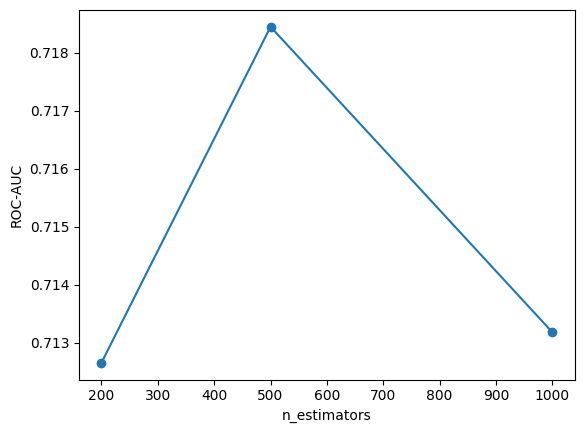

In [66]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_samples': [0.1],
    'max_features': [3],
    'bootstrap': [True],
}

reports = []

# Keep track of the max_samples values used for the plots
max_samples_values = []

for n_estimators in param_grid['n_estimators']:
    for max_samples_val in param_grid['max_samples']:
        for max_features in param_grid['max_features']:
            for bootstrap in param_grid['bootstrap']:


              smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
              #Balancing of train dataset
              X_train_res, y_train_res = smote.fit_resample(X_train_fold, Y_train_fold)

                 #Model parameters
              model = RandomForestClassifier(
               n_estimators=n_estimators,
               max_samples=max_samples_val,
               max_features=max_features,
               bootstrap=bootstrap,
               random_state=42
              )

              #Training of model
              model.fit(X_train_res, y_train_res)

              # Probabaility estimate of of employees leaving
              y_proba = model.predict_proba(X_test_fold)[:,1]


              #Computation of area under the Receiver operating characteristics (ROC AUC)
              #Parameter 1 - true labels
              #Parameter 2 - probability estimate
              report = roc_auc_score(Y_test_fold,y_proba)
              reports.append(report)
              max_samples_values.append(n_estimators)

print(reports)

#Plot the max_samples_values (n_estimators) versus rocauc_score
plt.plot(max_samples_values, reports, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("ROC-AUC")
plt.show()


Chapter 5.2.8 MAX_FEATURES

 Building and training of Models explaining parameters

[0.7024894810659188, 0.7207223001402524, 0.7210729312762973]


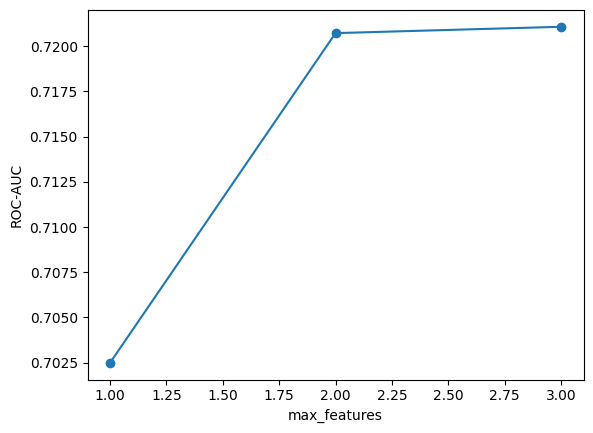

In [67]:

param_grid = {
    'n_estimators': [100],
    'max_samples': [0.1],
    'max_features': [1,2,3],
    'bootstrap': [True],
}

reports = []

# Keep track of the max_samples values used for the plots
max_samples_values = []

for n_estimators in param_grid['n_estimators']:
    for max_samples_val in param_grid['max_samples']:
        for max_features in param_grid['max_features']:
            for bootstrap in param_grid['bootstrap']:

              smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
              #Balancing of train dataset
              X_train_res, y_train_res = smote.fit_resample(X_train_fold, Y_train_fold)

                  #Model parameters
              model = RandomForestClassifier(
               n_estimators=n_estimators,
               max_samples=max_samples_val,
               max_features=max_features,
               bootstrap=bootstrap,
               random_state=42
              )

              #Training of Random Forest
              model.fit(X_train_res, y_train_res)

              #   # Probabaility estimate of of employees leaving
              y_proba = model.predict_proba(X_test_fold)[:,1]

               #Computation of area under the Receiver operating characteristics (ROC AUC)
              #Parameter 1 - true labels
              #Parameter 2 - probability estimate
              report = roc_auc_score(Y_test_fold,y_proba) # Corrected to use y_proba
              reports.append(report)
              max_samples_values.append(max_features)

print(reports)


plt.plot(max_samples_values, reports, marker='o')
plt.xlabel("max_features")
plt.ylabel("ROC-AUC")
plt.show()

MAX_Samples Chapter 5.2.8


Building and training of Models explaining parameters

[0.7210729312762973, 0.7186185133239833]


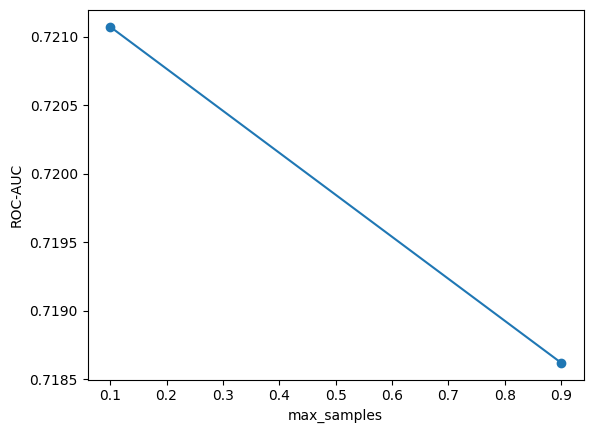

In [68]:
param_grid = {
    'n_estimators': [100],
    'max_samples': [0.1,0.9],
    'max_features': [3],
    'bootstrap': [True],
}

reports = []

# Keep track of the max_samples values used for the plots
max_samples_values = []

for n_estimators in param_grid['n_estimators']:
    for max_samples_val in param_grid['max_samples']:
        for max_features in param_grid['max_features']:
            for bootstrap in param_grid['bootstrap']:

                  #Balancing of train dataset
              smote = SMOTENC(categorical_features=categorical_indices, random_state=42)
              X_train_res, y_train_res = smote.fit_resample(X_train_fold, Y_train_fold)

                 #   #Model parameters
              model = RandomForestClassifier(
               n_estimators=n_estimators,
               max_samples=max_samples_val,
               max_features=max_features,
               bootstrap=bootstrap,
               random_state=42
              )

                 #Training of Random Forest
              model.fit(X_train_res, y_train_res)

              # Predict on validation fold
              y_proba = model.predict_proba(X_test_fold)[:,1]

              report = roc_auc_score(Y_test_fold,y_proba)
              reports.append(report)
              max_samples_values.append(max_samples_val)

print(reports)


plt.plot(max_samples_values, reports, marker='o')
plt.xlabel("max_samples")
plt.ylabel("ROC-AUC")
plt.show()

Dissertation Reference, Chapter 5.2.9 Interpretability

Establish dataframe that has pre-processed dataset (not balanced, employee number and chosen graphic feature.)

Split dataframe into 3 sub-sets:

X - all features but label and employee number

Y - labels

employee ref = employee numbers

In [69]:
##Dataframe representing the origial pre-processed dataset (not balanced), employee number and graphical feature (harmonic centrality )
combined = df_combo.copy()

#Save index and employee number in a dataframe called employee_ref
employee_ref = combined['EmployeeNumber']

Y = combined['Attrition']
X = combined.drop(['Attrition', 'EmployeeNumber'], axis=1)


Get Dataset ready for SMOTENC by identifying categorical indices

In [70]:

#Get the index number of the categorical feature which will later be used as part of SMOTENC
categorical_indices = X.select_dtypes(include=['category']).columns
categorical_indices = [X.columns.get_loc(col) for col in categorical_indices]
print(categorical_indices)

[0, 2, 3, 4, 8, 9, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


Split dataset into appropriote splits for training and testing of ML model

In [71]:

#Train# Test # Split
 #Split data into random train and test subsets
    # X and Y are the inputs i.e. the dataframe and series.
    #Industry standard proportion of 20% test size was opted for.
    #Permitting a random state = 42 (i.e. an int) controls shuffling and permits reproducability.
    #X_train, y_train are used for training and fitting model
    #X_test, y_test are used for testing and fitting model

X_train, X_test, y_train, y_test, employee_ref_train, employee_ref_test = train_test_split(
X, Y, employee_ref, test_size=0.2, random_state=42)

Balance training set whilst training Random Forest (rfn)

Initalise shap and get shap_values.

Sanity check shap_values i.e. based on number of clases, predictions and features.

In [72]:
#Smoten applied only on training data
#Parameter passing an array of indices specifying the categorical features.
#Rnadom state = 42 controlling random state of algo
#A default overration was opted for this means that the ratio of minority to majority class must be 1
smote_f = SMOTENC(
categorical_features=categorical_indices,
random_state=42)

#Resampling of dataset.
#Para 1 = data which has to be sampled
#Para 2 = label for each sample in Para 1
#Returns) X_train_reasampled, array with re-sampled data
#Returns Y_train_reasampled, label of x_train_resampled
X_train_resampled, y_train_resampled = smote_f.fit_resample(X_train, y_train)


rfn = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rfn.fit(X_train_resampled, y_train_resampled)

#predicted results
#print(classification_report(y_test, y_pred))

#Initialising SHAP treeexplainer for the random forest model.
#Uses tree shap algos to explain the output of ensemble tree models.
#Parameter 1: trained model.
explainer = shap.TreeExplainer(rfn)

#Uses shapley values to explain any machine learning model
#Calculating shap values for test set in relation to rfn
shap_values = explainer.shap_values(X_test)

#print(shap_values.shape)
#Since we have 294 rows by 44 features
print(f"SHAP values calculated for {shap_values.shape[0]} predictions")
print(f"Each prediction explained by {shap_values.shape[1]} features")
print(f"This is a classification having {shap_values.shape[2]} classes")


SHAP values calculated for 294 predictions
Each prediction explained by 37 features
This is a classification having 2 classes


Improve readability by adding feature label 'EmployeeNumber'

In [73]:

#This is limited to the group of employees ID that are in the test group i.e. not trained with.
#This has the index and Employee Number
#Consider this as being existing employees at company
employeetoindexdf = employee_ref_test.to_frame(name="EmployeeNumber")
print(employeetoindexdf)

     EmployeeNumber
1041           1469
184             250
1222           1714
67               86
220             304
...             ...
567             786
560             775
945            1317
522             715
651             903

[294 rows x 1 columns]


**EMPLOYEE LEVEL**



pred-all, Establish leavers (in terms of 1 = leave, 0 = stay)
y_prob, proabability of employee leaving (1 high chance of leaving, 0 remote chance of leaving)


y_pred_series, combine pred_all with employee index.

y_prob_series, establish probability of an employee staying or leaving (1 higher proabability of leaving, 0 very likely to stay) alongside employee index.

In [74]:
#Classify all employees, put results in a numpy array, 1 = leave and 0 = stay
pred_all = rfn.predict(X_test)
#Sanity Check results
#print((pred_all))
#print(employeetoindexdf)

#Combination of prediction results (leave or not leave) into a series combined with the index of employeetoindex not the employee number
y_pred_series = pd.Series(pred_all, index=employeetoindexdf.index)
#Sanity check results
#print(y_pred_series)


#Consider the proababiliy of leaving across all employee
y_prob = rfn.predict_proba(X_test)[:, 1]
#Sanity Checking results
#print(y_prob)

#Combination of prediction results (proabability of leaving) into a series combined with the index of employeetoindex, not the employee number
y_prob_series = pd.Series(y_prob, index=employeetoindexdf.index)
print(y_prob_series)


1041    0.210000
184     0.090000
1222    0.346667
67      0.156667
220     0.116667
          ...   
567     0.136667
560     0.220000
945     0.193333
522     0.383333
651     0.150000
Length: 294, dtype: float64


Create a high level employee summary, containing employee number and proabability of leaving


In [75]:

#Copying of employee number and index into new dataframe called 'employeetoindexrdf'
employeetoindexrdf = employeetoindexdf.copy()
#print(employeetoindexrdf)

#Combining results with previously generated series which identifies a leaver (1) or stayer (0) based on a binary number
employeetoindexrdf['IsAttrition'] = y_pred_series

#Combining results with previously generated series which identifies probability of leaving
employeetoindexrdf['LeaveProbability'] = y_prob_series

#Identifyng those employees that are predicted to leave alongside their proabability of leaving
#Filter by leavers
Leavers = employeetoindexrdf[employeetoindexrdf['IsAttrition'] == 1]

#Order by proabability of leaving
Leavers_sorted = Leavers.sort_values(by ='LeaveProbability', ascending = False)

#Sanity Check Results
#print(Leavers_sorted)

#As per user expectations drop isAttrition this is redundant
Leavers_sorted = Leavers_sorted.drop(columns=['IsAttrition'])

#This will only output the index, employee number, leave proabability
print(Leavers_sorted)
Leavers.to_csv('Leavers_sorted.csv', index=True)



     EmployeeNumber  LeaveProbability
363             485          0.986667
1196           1678          0.890000
946            1318          0.873333
921            1286          0.870000
416             556          0.830000
892            1248          0.823333
51               65          0.753333
239             331          0.746667
811            1125          0.690000
422             566          0.686667
665             925          0.683333
107             142          0.683333
573             796          0.673333
777            1079          0.660000
1319           1853          0.653333
1192           1674          0.640000
889            1244          0.640000
1422           2003          0.633333
30               39          0.630000
494             666          0.623333
917            1281          0.613333
361             483          0.613333
270             374          0.590000
350             470          0.563333
168             230          0.563333
1335        

Employee SHAP Attempt Proof of Concept

Get shap output to work well for a single employee as a proof of concept and to begin discussiosn with HR professionals

6


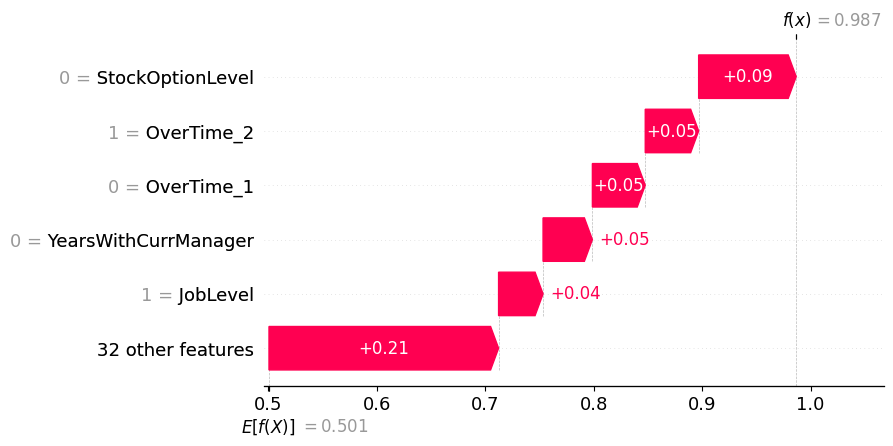

In [76]:


# Only conidering employees at risk of leaving
X_test_keep = X_test[X_test.index.isin(Leavers.index)]

#Sanity check filter worked as expected
#This outputs a list of all features that were used to train model
#print(X_test_keep)


##SHAP ONLY ON THE LIMITED PART OF TEST RELATED TO LEAVES
#Initialising SHAP treeexplainer for the random forest model.
#Uses tree shap algos to explain the output of ensemble tree models.
#Parameter 1: trained model.
#explainer = shap.TreeExplainer(rfn)

#Uses shapley values to explain any machine learning model
#Calculating shap values for test set in relation to rfn
shap_values = explainer.shap_values(X_test_keep)

#Testing with a single employee
EmployeeNumber = 485
#An employee Number = 485 has a corresponding index of 363

# Based on an Employee extract a df of one row only which has that employee details
# Ensure types match for comparison
employee_row_df = Leavers_sorted[Leavers_sorted['EmployeeNumber'] == str(EmployeeNumber)]

#Prints details of that row to ensure extract is working, employee number, proababiliy of leaving and index
#print(employee_row_df)

#Get the index of the Row in this case its 363 and rename to original row index as this was the index found in the original dataset.
original_row_index = employee_row_df.index[0]
#Sanity check result is 363
#print(original_row_index)

# Find the positional index of this label within X_test's current index
# This is important for the shap_values
positional_index_in_X_test = X_test_keep.index.get_loc(original_row_index)
#Expected value of 6, Sanity checking
print(positional_index_in_X_test)

#Attempting explainability for a single employee having position 6 i.e. employee number = 485 having an original index of 363
shap_values_for_instance = shap_values[positional_index_in_X_test, :, 1]
#print(shap_values_for_instance)

#Create a shap waterfall plot
plt.figure(figsize=(12,8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_for_instance,
        base_values=explainer.expected_value[1],
        data=X_test_keep.loc[original_row_index].values,
        feature_names = X_test.columns.tolist()
    ),
    max_display=6
)

plt.close(fig)

Implementing fixes as recommended by HR professionals for a SINGLE Employee (part of improvement process)
- Main Fixes involved reversing encoding effort by grouped encoded shap values and creating a new label to group them.

Employee Number: 485


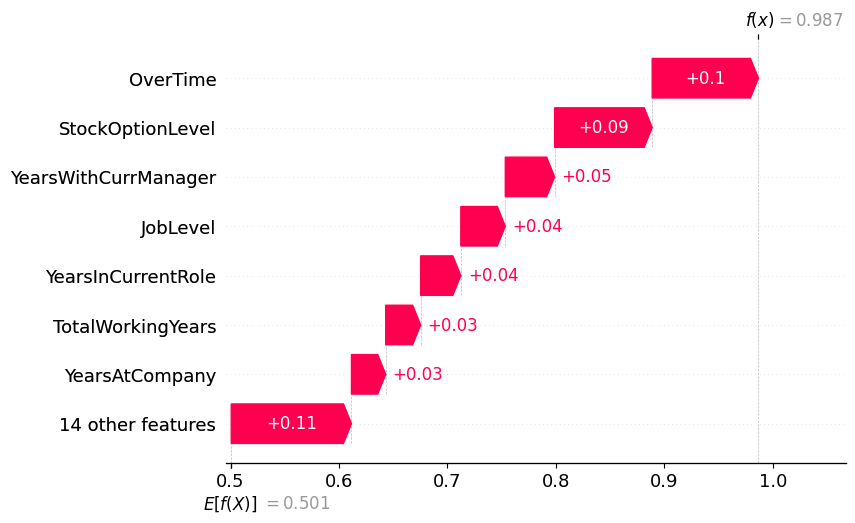

In [77]:
import matplotlib.pyplot as plt


#Identification of those features that where one hot encoded.
#Creating a list to re-group them as they would have been in the original dataset.
dept_cols = ["Department_1", "Department_2", "Department_3"]
OT_cols = ["OverTime_1", "OverTime_2"]
EF_cols = ["EducationField_1", "EducationField_2", "EducationField_3", "EducationField_4", "EducationField_5", "EducationField_6" ]
JR_cols = ["JobRole_1", "JobRole_2", "JobRole_3", "JobRole_4", "JobRole_5", "JobRole_6", "JobRole_7", "JobRole_8", "JobRole_9" ]

#This represents the actual shap values related to a particular employee
#print(shap_values_for_instance)

#Assigning shap values to their features
# We have shap values and corresping features
shap_s = pd.Series(shap_values_for_instance, index=X_test_keep.columns)
#print(shap_s)


#sum shap value for for department
dept_shap = shap_s[dept_cols].sum()
#sum shap value for Job Role
JR_shap = shap_s[JR_cols].sum()
#sum shap values for OT
OT_shap = shap_s[OT_cols].sum()
#Sum shap values for EF
EF_shap = shap_s[EF_cols].sum()


#List creation for shap values,
# New values will store summed shap values.
# new names will re-organise column titles accordingly
new_values = []
new_names = []



#Loop through all columns of test data set, DO NOT consider those columns whereby onehot encoding previously occured.
for col in X_test.columns:
    if col in dept_cols or col in OT_cols or col in EF_cols or col in JR_cols:
        #Sanity Testing
        #print(col)
        continue
        #Sanity Testing
        #print(col)
    #Consider specific shap values for a specific feature column and add to end of list
    new_values.append(shap_s[col])
    new_names.append(col)
    #Sanity Testing Results
    #print(new_values)
    #print(new_names)



##Consider those values which where hot encoded
# Add combined department at the end
new_values.append(dept_shap)
#new_data.append(dept_name)
new_names.append("Department")

#Add combined values at the end
new_values.append(OT_shap)
#new_data.append(OT_name)
new_names.append("OverTime")

#Add combined values at the end
new_values.append(EF_shap)
#new_data.append(EF_name)
new_names.append("EducationField-")

#Add combined values at the end
new_values.append(JR_shap)
#new_data.append(JR_name)
new_names.append("JobRole-")


plt.figure(figsize=(12,8))
print(f"Employee Number: {EmployeeNumber}")

shap.waterfall_plot(
    shap.Explanation(
        values=np.array(new_values),
        base_values=explainer.expected_value[1],
        feature_names=new_names
    ),
    max_display=8,



)

plt.close(fig)


Save all leavers as images this will make them easily availiable for dashboard

Note code is same as above but with a loop for all employees and saving results as an image.





In [78]:
# Loops through all empployees in Data Frame


for employee_no in Leavers_sorted.EmployeeNumber:
  print(employee_no)

  #Store Employee number
  EmployeeNumber = employee_no
  #index of 51 in the dataframe

  # A df of one row only which has Employee Number, Leave proabability and the original Index
  # Ensure types match for comparison
  employee_row_df = Leavers_sorted[Leavers_sorted['EmployeeNumber'] == EmployeeNumber]
  #Sanity Check
  #print(employee_row_df)

  #Get the original index of the Row
  original_row_index = employee_row_df.index[0] # Renaming index_no to original_row_label for consistency
  #Sanity Check
  #print(original_row_index)

  # Find the positional index of this label within X_test's current index
  # This is important for the shap_values
  positional_index_in_X_test = X_test_keep.index.get_loc(original_row_index)
  #print(positional_index_in_X_test)

  shap_values_for_instance = shap_values[positional_index_in_X_test, :, 1]



  #Identification of those features that where one hot encoded.
  #Creating a list to re-group them as they would have been in the original dataset.
  dept_cols = ["Department_1", "Department_2", "Department_3"]
  OT_cols = ["OverTime_1", "OverTime_2"]
  EF_cols = ["EducationField_1", "EducationField_2", "EducationField_3", "EducationField_4", "EducationField_5", "EducationField_6" ]
  JR_cols = ["JobRole_1", "JobRole_2", "JobRole_3", "JobRole_4", "JobRole_5", "JobRole_6", "JobRole_7", "JobRole_8", "JobRole_9" ]


  shap_s = pd.Series(shap_values_for_instance, index=X_test_keep.columns)




  #value for employee
  #x_s = X_test_keep.loc[original_row_index]
  #print(x_s)



  #sum shap value for encoding columns
  dept_shap = shap_s[dept_cols].sum()
  JR_shap = shap_s[JR_cols].sum()
  OT_shap = shap_s[OT_cols].sum()
  EF_shap = shap_s[EF_cols].sum()



  #dept_name = x_s[dept_cols].idxmax().replace("department_", "Dept ")
  #OT_name = x_s[OT_cols].idxmax().replace("OverTime_", "OverTime ")
  #EF_name = x_s[EF_cols].idxmax().replace("EducationField_", "EducationField-")
  #JR_name = x_s[JR_cols].idxmax().replace("JobRole_", "JobRole-")



 #List creation for shap values,
# New values will store summed shap values.
# new names will re-organise column titles accordingly

  new_values = []

  new_names = []



#Loop through all columns of test data set, DO NOT consider those columns whereby onehot encoding previously occured.
  for col in X_test.columns:
      if col in dept_cols or col in OT_cols or col in EF_cols or col in JR_cols:
          continue

    #Consider specific shap values for a specific feature column and add to end of list
      new_values.append(shap_s[col])
      new_names.append(col)

  # Add combined department at the end
  new_values.append(dept_shap)
  new_names.append("Department")

  #Add combined values at the end
  new_values.append(OT_shap)
  new_names.append("OverTime")

  #Add combined values at the end
  new_values.append(EF_shap)
  new_names.append("EducationField-")

  #Add combined values at the end
  new_values.append(JR_shap)
  new_names.append("JobRole-")



  fig = plt.figure(figsize=(12, 8))


  shap.waterfall_plot(
      shap.Explanation(
          values=np.array(new_values),
          base_values=explainer.expected_value[1],
          feature_names=new_names
      ),
      max_display=8,
      show = False
  )

  fig = plt.gcf()


  plt.savefig(
      f"{str(employee_no)}_Employee_attrition.jpg", dpi = 1000, bbox_inches="tight", pad_inches=0.3, transparent=True)
  plt.close(fig)





485
1678
1318
1286
556
1248
65
331
1125
566
925
142
796
1079
1853
1674
1244
2003
39
666
1281
483
374
470
230
1871
63
964
475


In [ ]:
'''from google.colab import drive
drive.mount('/content/drive')'''

**Organisational Level**

Generate shap at an organiational level whilst considering HR feedback.

In [79]:
# Only conidering employees at risk of leaving
X_test_keep_org = X_test_keep

#Uses shapley values to explain any machine learning model
#Calculating shap values for test set in relation to rfn
shap_values_org = explainer.shap_values(X_test_keep_org)

#Sanity Checking output to identify categorical variables which would need to be modified
#X_test_keep_org

#Utilising previously defined data defintion for categorical features to modify feature labels and strategic pillars

X_test_keep_org = X_test_keep_org.rename(columns={"OverTime_1": "Work Enviroment: Does no Overtime(High=yes)",
                                                "OverTime_2": "Work Enviroment: Does Overtime(High=yes)"})

X_test_keep_org = X_test_keep_org.rename(columns={"Department_1": "Work Enviroment: Department HR (high=yes)",
                                                "Department_2": "Work Enviroment: Department RD (High=yes)",
                                                "Department_3": "Work Enviroment: Department Sales(High=yes)" })

X_test_keep_org = X_test_keep_org.rename(columns={"EducationField_1": "Personal: Education Field HR (high=yes)",
                                                "EducationField_2": "Personal: Education Field Life Sciences (high=yes)",
                                                "EducationField_3": "Personal: Education Field Marketing (high=yes)",
                                                "EducationField_4": "Personal: Education Field Medical (high=yes)",
                                                "EducationField_5": "Personal: Education Field Other (high=yes)",
                                                "EducationField_6": "Personal: Education Field Technical Degree (high=yes)",
                                                })
X_test_keep_org = X_test_keep_org.rename(columns={"JobRole_1": "Work Enviroment: Job Role Health Care Rep (High=Yes)",
                                                "JobRole_2": "Work Enviroment: Job Role Human Resource (High=Yes)",
                                                "JobRole_3": "Work Enviroment: Job Role Lab Technician (High=Yes)",
                                                "JobRole_4": "Work Enviroment: Job Role Manager (High=Yes)",
                                                "JobRole_5": "Work Enviroment: Job Role Manu Director (High=Yes)",
                                                "JobRole_6": "Work Enviroment: Job Role Research Dir (High=Yes)",
                                                "JobRole_7": "Work Enviroment: Job Role Research Scientist (High=Yes)",
                                                "JobRole_8": "Work Enviroment: Job Role Sales Executive (High=Yes)",
                                                "JobRole_9": "Work Enviroment: Job Role Sales Rep (High=Yes)",
                                                })


X_test_keep_org = X_test_keep_org.rename(columns={"StockOptionLevel": "Management/Culture: Stock Options (High = more stock) "
                                                                                                })


X_test_keep_org = X_test_keep_org.rename(columns={"MonthlyIncome": "Management/Culture: Monthly Income (High = higher income) "
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"JobLevel": "Work Enviroment: Job Level (higher = more seniority) "
                                                                                                })


X_test_keep_org = X_test_keep_org.rename(columns={"YearsWithCurrManager": "People: Years with Current Manager"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"YearsInCurrentRole": "Management/Culture: Years in Current Role"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"YearsAtCompany": "People: Years at Company"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"TrainingTimesLastYear": "Work Enviorment: Training Times Last Year"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"TotalWorkingYears": "People: Total Working Years"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"DistanceFromHome": "External Enviroment: Distance from Home"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"NumCompaniesWorked": "Personal: Number of Companies Worked"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"YearsSinceLastPromotion": "Management/Culture: Years Since Last Promotion"
                                                                                                })



X_test_keep_org = X_test_keep_org.rename(columns={"PerformanceRating": "People: Performance Rating (High = Higher Rating)"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"Education": "Personal: Education (High = Higher Rating)"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"BusinessTravel": "Work Enviroment: Business Travel (High = More Frequent travel"})
X_test_keep_org = X_test_keep_org.rename(columns={"PercentSalaryHike": "Management/Culture: Percent Salary Hike (High = Higher Raise)"
                                                                                                })

X_test_keep_org = X_test_keep_org.rename(columns={"JobInvolvement": "Work Enviroment: Job Involvement (High = Higher Involvement)"
                                                                                                })



shap.plots.violin(shap.Explanation(

    values=shap_values_org[:, :, 1],
    #base_values=explainer.expected_value[1],

    data=X_test_keep_org.values,

    #Refers to the list of feature labels that where just modified i.e. strategic pillar and feature column
    feature_names=X_test_keep_org.columns.tolist()
), max_display=5, show= False

)

plt.savefig("Organisation_attrition.jpg", dpi = 1000, bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.close(fig)


**Departamental Level**

In [80]:
# Utilise the renamed feature labels for X_test_keep_org
X_test_keep_dep = X_test_keep_org

#Sanity Checking columns names for next step.
#print(X_test_keep_dep.dtypes)

#Splitting testing data by department
X_test_keep_HR = X_test_keep_dep[X_test_keep_dep['Work Enviroment: Department HR (high=yes)'] == 1]
X_test_keep_RD = X_test_keep_dep[X_test_keep_dep['Work Enviroment: Department RD (High=yes)'] == 1]
X_test_keep_Sales = X_test_keep_dep[X_test_keep_dep['Work Enviroment: Department Sales(High=yes)'] == 1]


#Uses shapley values to explain any machine learning model
#Calculating shap values for test set in relation to rfn

#Shap for each department
shap_values_HR = explainer.shap_values(X_test_keep_HR)
shap_values_RD = explainer.shap_values(X_test_keep_RD)
shap_values_Sales = explainer.shap_values(X_test_keep_Sales)


#plotting and saving each departments plot

#HR
fig, ax = plt.subplots(figsize=(8, 6))

shap.plots.violin(shap.Explanation(

    values=shap_values_HR[:, :, 1],


    data=X_test_keep_HR.values,


    feature_names=X_test_keep_dep.columns.tolist()
), max_display=5, show = False

)

plt.savefig("HR_DEPARTMENT.jpg", dpi = 1000, bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.close(fig)


#RD
fig, ax = plt.subplots(figsize=(8, 6))

shap.plots.violin(shap.Explanation(

    values=shap_values_RD[:, :, 1],


    data=X_test_keep_RD.values,


    feature_names=X_test_keep_dep.columns.tolist()
), max_display=5,show = False

)

plt.savefig("RD_DEPARTMENT.jpg", dpi = 1000, bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.close(fig)


#SALES
fig, ax = plt.subplots(figsize=(8, 6))

shap.plots.violin(shap.Explanation(

    values=shap_values_Sales[:, :, 1],


    data=X_test_keep_Sales.values,


    feature_names=X_test_keep_dep.columns.tolist()
), max_display=5, show = False

)

plt.savefig("SALES_DEPARTMENT.jpg", dpi = 1000, bbox_inches="tight", pad_inches=0.3, transparent=True)
plt.close(fig)


**MODEL PERFORMANCE**

Extract performance metrics from top performing model (graphical features) and format in a manner so as to be easily retrievable.
Subsequently save results to a csv

In [81]:
print(final_metrics_graphicfeature)

              precision  recall  f1-score  support
0                  0.89    0.92      0.90   123.30
1                  0.48    0.39      0.42    23.70
accuracy           0.83    0.83      0.83     0.83
macro avg          0.68    0.65      0.66   147.00
weighted avg       0.82    0.83      0.82   147.00


In [82]:
# Extract peformance metrics from previoulsy created data frame and put into a format which is easily extractable




precision_class0 = final_metrics_graphicfeature.loc['0']['precision']
recall_class0 = final_metrics_graphicfeature.loc['0']['recall']
f1_class0 = final_metrics_graphicfeature.loc['0']['f1-score']

precision_class1 = final_metrics_graphicfeature.loc['1']['precision']
recall_class1 = final_metrics_graphicfeature.loc['1']['recall']
f1_class1 = final_metrics_graphicfeature.loc['1']['f1-score']

accuracy = final_metrics_graphicfeature.loc['accuracy']['precision']

#initalise a list of results
data = [ {'Stay Class': precision_class0, 'Leave Class': precision_class1},
        {'Stay Class': recall_class0, 'Leave Class': recall_class1},
         {'Stay Class': f1_class0, 'Leave Class': f1_class1 } ]


#Creation of dataframe having 3 indexes to store precision, recall and f1
dfperformancemetrics = pd.DataFrame(data, index = ['Precision', 'Recall', 'F1'])

#Create a dataframe to store accuracy
dfacc = pd.DataFrame(data = [accuracy], index = ['Accuracy'])

print(dfperformancemetrics)
print(dfacc)

#Saving results to a csv to be easily retrievable for streamlit.
dfperformancemetrics.to_csv('dfperformancemetrics.csv', index=True)
dfacc.to_csv('dfperformanceacc.csv', index=True)

           Stay Class  Leave Class
Precision        0.89         0.48
Recall           0.92         0.39
F1               0.90         0.42
             0
Accuracy  0.83


**Correleations**

In [83]:
#Sanity checking feature columns are correct.
#print(df_RAW['OverTime'])
#print(df_RAW['JobLevel'])
#print(df_RAW['StockOptionLevel'])
#print(df_RAW['JobRole'])
#print(df_RAW['Attrition'])

#Create a new dataframe which will have required features to analyse
dfcorreleations = df_RAW[['OverTime', 'Attrition', 'JobRole', 'JobLevel', 'StockOptionLevel']]

#Sanity Check
#print(dfcorreleations)


#DataDictionary to cater for categorical features this will help improve readability further downstream related to cross-tabulation tables and correleation plots.
StockoptionMap = {
    0: "No",
    1: "Basic Level of Stock",
    2: "Medium Level of Stock",
    3: "High Level of Stock",
}



JobLevelMap = {
    1: "Entry",
    2: "Associate",
    3: "Middle-Management",
    4: "Head",
    5: "C-Level",
}

#Replacing technical keys with semantic descriptions
dfcorreleations['StockOptionLevel'] = dfcorreleations['StockOptionLevel'].map(StockoptionMap)
dfcorreleations['JobLevel'] = dfcorreleations['JobLevel'].map(JobLevelMap)

#Sanity Checking Results
#print(dfcorreleations)

#Saving results for later.
dfcorreleations.to_csv('dfcorreleations.csv', index=True)



#Provided HR professionals with an early draft.
#dfcorreleations = pd.read_csv('/content/dfcorreleations.csv', index_col =0)
#print(dfcorreleations)


 #Diagram 1
#res = pd.crosstab(dfcorreleations.StockOptionLevel, dfcorreleations.Attrition)
#print(res)


/tmp/ipykernel_1797/3641351800.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfcorreleations['StockOptionLevel'] = dfcorreleations['StockOptionLevel'].map(StockoptionMap)
/tmp/ipykernel_1797/3641351800.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfcorreleations['JobLevel'] = dfcorreleations['JobLevel'].map(JobLevelMap)


**LEAVER VISUALISATION**

Prepping a CSV highlighting the leavers and their job roles which will eventually be displayed graphically.

In [84]:
df_raw['EmployeeNumber'] = df_raw['EmployeeNumber'].astype(str)

leavers_graph = pd.merge(Leavers_sorted, df_raw, on='EmployeeNumber', how='left')
leavers_graph_selected = leavers_graph[["EmployeeNumber", "JobRole" ]]

print(leavers_graph_selected)
leavers_graph_selected.to_csv('dfleaversgraph.csv', index=True)


   EmployeeNumber                JobRole
0             485   Sales Representative
1            1678        Sales Executive
2            1318        Sales Executive
3            1286  Laboratory Technician
4             556  Laboratory Technician
5            1248     Research Scientist
6              65  Laboratory Technician
7             331  Laboratory Technician
8            1125        Sales Executive
9             566        Human Resources
10            925   Sales Representative
11            142        Sales Executive
12            796        Sales Executive
13           1079  Laboratory Technician
14           1853        Sales Executive
15           1674  Laboratory Technician
16           1244     Research Scientist
17           2003  Laboratory Technician
18             39  Laboratory Technician
19            666   Sales Representative
20           1281        Sales Executive
21            483  Laboratory Technician
22            374                Manager
23            47